# Feature Engineering and Modelling Set Preparation - Non-Invasive vs Invasive Architecture

## Introduction
This notebook is preparing the two modelling sets used in the thesis. Both models are training on the same cleaned clinical PCOS cohort with 541 patients. This design is making the comparison fair because any performance difference will come from the feature groups, not from different source populations.

The first model is the **Non-Invasive Clinical Screening Model**. It is using routine clinical features that can be collected without hormonal testing or ultrasound. The second model is the **Invasive Benchmark Model**. It is using only hormonal and ultrasound-derived features from the same cohort. This setup is supporting a clean ablation-style comparison between routine screening information and invasive clinical information.

This notebook is saving every modelling file needed by the downstream training notebooks. That includes train and test splits, saved feature-name files, saved scalers, a shared cross-validation object, and the survey-based external-style validation set. Centralising this work here is protecting the integrity of later model comparisons.

All downstream modelling notebooks must load their prepared data from `cleaned_data/modelling_sets/`. They must **not** split, scale, balance, or refit preprocessing on their own. This notebook is the single source of truth for modelling preparation in this project.

## Output Files Produced in This Notebook
| Output File | Purpose |
| --- | --- |
| `model1_train.csv` | SMOTE-balanced, scaled training set for the non-invasive model. |
| `model1_test.csv` | Scaled held-out test set for the non-invasive model. |
| `model2_train.csv` | SMOTE-balanced, scaled training set for the invasive model. |
| `model2_test.csv` | Scaled held-out test set for the invasive model. |
| `survey_external_validation.csv` | Survey-based external-style validation table aligned to the Model 1 contract. |
| `feature_names_model1.json` | Ordered feature list for the non-invasive model. |
| `feature_names_model2.json` | Ordered feature list for the invasive model. |
| `scaler_model1.pkl` | Saved MinMaxScaler fitted on Model 1 training data only. |
| `scaler_model2.pkl` | Saved MinMaxScaler fitted on Model 2 training data only. |
| `cv_strategy.pkl` | Shared stratified cross-validation object for downstream notebooks. |


## Section 1 - Imports and Global Configuration

This section is importing the libraries, setting the shared constants, and preparing the reusable helper functions used across the notebook.


In [66]:
# Importing the libraries is preparing the notebook for loading data, engineering features, plotting summaries, and saving reusable artifacts.
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from scipy import stats
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 150
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_CV_FOLDS = 10
TARGET = "pcos_y_n"

COLORS = {
    "pcos_pos": "#E63946",
    "pcos_neg": "#457B9D",
    "model1": "#2A9D8F",
    "model2": "#E9C46A",
    "neutral": "#2C3E50",
    "highlight": "#F4A261",
}


In [67]:
# Resolving the project paths and creating the output directories is making the notebook reproducible across different run locations.
def resolve_project_root() -> Path:
    current = Path.cwd().resolve()
    candidates = [current, current.parent, current.parent.parent]
    for candidate in candidates:
        if (candidate / "cleaned_data").exists() and (candidate / "images").exists():
            return candidate
    return current

PROJECT_ROOT = resolve_project_root()
CLINICAL_PATH = PROJECT_ROOT / "cleaned_data" / "PCOS_full_cleaned.csv"
SURVEY_PATH = PROJECT_ROOT / "cleaned_data" / "PCOS_survey_cleaned.csv"
MODELLING_DIR = PROJECT_ROOT / "cleaned_data" / "modelling_sets"
MODELS_DIR = PROJECT_ROOT / "models"
IMAGE_DIR = PROJECT_ROOT / "images" / "feature_engineering"

MODELLING_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Created or confirmed: {MODELLING_DIR}")
print(f"Created or confirmed: {MODELS_DIR}")
print(f"Created or confirmed: {IMAGE_DIR}")


Created or confirmed: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets
Created or confirmed: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models
Created or confirmed: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\feature_engineering


In [68]:
# Defining small helper functions is keeping repeated plotting, annotation, and train-only imputation logic consistent.
def save_figure(fig: plt.Figure, file_name: str) -> Path:
    output_path = IMAGE_DIR / file_name
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    return output_path

def annotate_bars(ax: plt.Axes, total: float | None = None, decimals: int = 0) -> None:
    for patch in ax.patches:
        height = patch.get_height()
        if np.isnan(height):
            continue
        if total is None:
            label = f"{height:.{decimals}f}"
        else:
            pct = (height / total) * 100 if total else 0
            label = f"{int(height)}\n({pct:.1f}%)"
        ax.annotate(
            label,
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=8,
            xytext=(0, 4),
            textcoords="offset points",
        )

def build_missing_table(frame: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    table = pd.DataFrame({
        "feature": features,
        "missing_count": frame[features].isnull().sum().values,
    })
    table["missing_pct"] = (table["missing_count"] / len(frame) * 100).round(2)
    return table

def build_fill_values(train_frame: pd.DataFrame, binary_cols: list[str], continuous_cols: list[str]) -> dict[str, float]:
    fill_values: dict[str, float] = {}
    for column in binary_cols:
        mode = train_frame[column].dropna().mode()
        fill_values[column] = float(mode.iloc[0]) if not mode.empty else 0.0
    for column in continuous_cols:
        fill_values[column] = float(train_frame[column].dropna().median())
    return fill_values

def apply_fill_values(frame: pd.DataFrame, fill_values: dict[str, float]) -> pd.DataFrame:
    filled = frame.copy()
    for column, value in fill_values.items():
        filled[column] = filled[column].fillna(value)
    return filled


## Section 2 - Loading and Validating Source Data

This section is loading the cleaned clinical dataset and the cleaned survey dataset, checking the target column, and confirming the source class balance before any modelling preparation begins.


In [69]:
# Loading the clinical and survey datasets is bringing the two source tables into the notebook and confirming their schemas.
df = pd.read_csv(CLINICAL_PATH)
survey_df = pd.read_csv(SURVEY_PATH)

print(f"Clinical dataset shape: {df.shape}")
print(f"Survey dataset shape  : {survey_df.shape}")
print()
print("Clinical columns:")
for idx, column in enumerate(df.columns):
    print(f"{idx:02d}: {column}")
print()
print("Survey columns:")
for idx, column in enumerate(survey_df.columns):
    print(f"{idx:02d}: {column}")
print()
print("Clinical dtypes:")
print(df.dtypes)


Clinical dataset shape: (541, 44)
Survey dataset shape  : (464, 20)

Clinical columns:
00: pcos_y_n
01: age_yrs
02: weight_kg
03: height_cm
04: bmi
05: blood_group_code
06: pulse_rate_bpm
07: respiratory_rate_breaths_min
08: hb_g_dl
09: cycle_regularity_code
10: cycle_length_days
11: marriage_status_yrs
12: pregnant_y_n
13: number_of_abortions
14: beta_hcg_i_miu_ml
15: beta_hcg_ii_miu_ml
16: fsh_miu_ml
17: lh_miu_ml
18: fsh_lh_ratio
19: hip_inch
20: waist_inch
21: waist_hip_ratio
22: tsh_miu_l
23: amh_ng_ml
24: prl_ng_ml
25: vit_d3_ng_ml
26: prg_ng_ml
27: rbs_mg_dl
28: weight_gain_y_n
29: hair_growth_y_n
30: skin_darkening_y_n
31: hair_loss_y_n
32: pimples_y_n
33: fast_food_y_n
34: regular_exercise_y_n
35: systolic_bp_mmhg
36: diastolic_bp_mmhg
37: follicle_no_left
38: follicle_no_right
39: avg_follicle_size_left_mm
40: avg_follicle_size_right_mm
41: endometrium_mm
42: bmi_calculated
43: waist_hip_ratio_calculated

Survey columns:
00: age_yrs
01: weight_kg
02: height_raw
03: blood_grou

In [70]:
# Validating the target column is confirming that the modelling target is present, binary, and free from missing values.
assert TARGET in df.columns, f"{TARGET} is missing from the clinical dataset."
assert TARGET in survey_df.columns, f"{TARGET} is missing from the survey dataset."

clinical_counts = df[TARGET].value_counts().sort_index()
survey_counts = survey_df[TARGET].value_counts().sort_index()

print("Clinical target counts:")
print(clinical_counts)
print()
print("Clinical target percentages:")
print((clinical_counts / len(df) * 100).round(2))
print()
imbalance_ratio = clinical_counts.loc[0] / clinical_counts.loc[1]
scale_pos_weight = imbalance_ratio
print(f"Clinical imbalance ratio (negative / positive): {imbalance_ratio:.4f}")
print(f"Suggested XGBoost scale_pos_weight             : {scale_pos_weight:.4f}")
print()
print("Survey target counts:")
print(survey_counts)
print()
print("Survey target percentages:")
print((survey_counts / len(survey_df) * 100).round(2))

assert df[TARGET].isin([0, 1]).all(), "Clinical target contains values outside 0 and 1."
assert survey_df[TARGET].isin([0, 1]).all(), "Survey target contains values outside 0 and 1."
assert df[TARGET].isnull().sum() == 0, "Clinical target contains missing values."
assert survey_df[TARGET].isnull().sum() == 0, "Survey target contains missing values."


Clinical target counts:
pcos_y_n
0    364
1    177
Name: count, dtype: int64

Clinical target percentages:
pcos_y_n
0   67.2800
1   32.7200
Name: count, dtype: float64

Clinical imbalance ratio (negative / positive): 2.0565
Suggested XGBoost scale_pos_weight             : 2.0565

Survey target counts:
pcos_y_n
0    363
1    101
Name: count, dtype: int64

Survey target percentages:
pcos_y_n
0   78.2300
1   21.7700
Name: count, dtype: float64


In [71]:
# Printing the source class table is documenting the exact counts behind the source class distribution plot.
source_class_table = (
    df[TARGET]
    .value_counts()
    .sort_index()
    .rename_axis("pcos_y_n")
    .reset_index(name="count")
)
source_class_table["percentage"] = (source_class_table["count"] / len(df) * 100).round(2)
print(source_class_table)


   pcos_y_n  count  percentage
0         0    364     67.2800
1         1    177     32.7200


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\feature_engineering\01_class_distribution_source.png


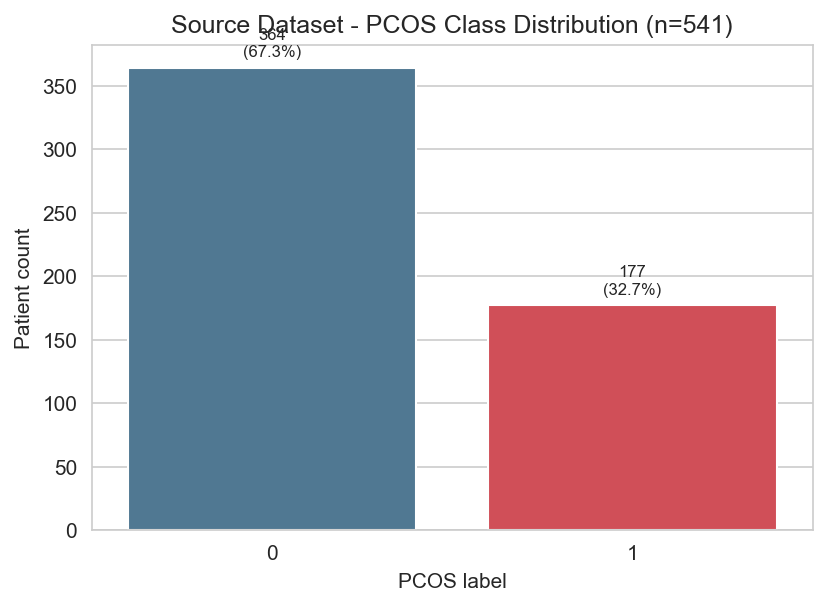

In [72]:
# Plotting the source class distribution is showing the class imbalance that downstream notebooks must respect on the test set.
fig, ax = plt.subplots(figsize=(6.2, 4.2))
sns.barplot(
    data=source_class_table,
    x="pcos_y_n",
    y="count",
    palette=[COLORS["pcos_neg"], COLORS["pcos_pos"]],
    ax=ax,
)
ax.set_title("Source Dataset - PCOS Class Distribution (n=541)")
ax.set_xlabel("PCOS label")
ax.set_ylabel("Patient count")
annotate_bars(ax, total=len(df))
output_path = save_figure(fig, "01_class_distribution_source.png")
print(f"Saved figure to: {output_path}")
plt.show()


## Section 3 - Cycle Regularity Harmonisation

This section is aligning the cycle regularity field across the clinical and survey datasets. The clinical table stores cycle regularity as a recorded code. The survey table stores the same idea as a binary field. Before defining the model contracts, the clinical code is being remapped into a shared binary field called `cycle_regularity_binary`.

For this notebook, the heuristic remap is being locked as:
- `2 -> 1` for regular cycles
- `4 -> 0` for irregular cycles
- `5 -> 0` for irregular cycles

This is a harmonisation decision for modelling. It is not a new data-cleaning step.


In [73]:
# Printing the clinical cycle code distribution is showing the original source values before remapping them into a binary feature.
print("cycle_regularity_code - value counts before remap:")
print(df["cycle_regularity_code"].value_counts().sort_index())
print()
print("Percentage breakdown:")
print(df["cycle_regularity_code"].value_counts(normalize=True).sort_index().mul(100).round(2))


cycle_regularity_code - value counts before remap:
cycle_regularity_code
2    390
4    150
5      1
Name: count, dtype: int64

Percentage breakdown:
cycle_regularity_code
2   72.0900
4   27.7300
5    0.1800
Name: proportion, dtype: float64


In [74]:
# Applying the heuristic remap is creating the shared binary cycle field used by Model 1 and by the survey alignment step.
remap_dict = {2: 1, 4: 0, 5: 0}
df["cycle_regularity_binary"] = df["cycle_regularity_code"].map(remap_dict)

print("cycle_regularity_binary - value counts after remap:")
print(df["cycle_regularity_binary"].value_counts().sort_index())
print()
print("Binary percentage breakdown:")
print(df["cycle_regularity_binary"].value_counts(normalize=True).sort_index().mul(100).round(2))

assert df["cycle_regularity_binary"].isnull().sum() == 0, "Binary cycle regularity contains missing values after remap."
assert set(df["cycle_regularity_binary"].unique()) == {0, 1}, "Binary cycle regularity contains values outside 0 and 1."
print()
print("cycle_regularity_binary created successfully.")


cycle_regularity_binary - value counts after remap:
cycle_regularity_binary
0    151
1    390
Name: count, dtype: int64

Binary percentage breakdown:
cycle_regularity_binary
0   27.9100
1   72.0900
Name: proportion, dtype: float64

cycle_regularity_binary created successfully.


In [75]:
# Printing the remap cross-tab is documenting the exact table behind the original-vs-binary remap plot.
cycle_remap_table = pd.crosstab(
    df["cycle_regularity_code"],
    df["cycle_regularity_binary"],
    rownames=["original_code"],
    colnames=["cycle_regularity_binary"],
)
print(cycle_remap_table)


cycle_regularity_binary    0    1
original_code                    
2                          0  390
4                        150    0
5                          1    0


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\feature_engineering\02_cycle_regularity_remap.png


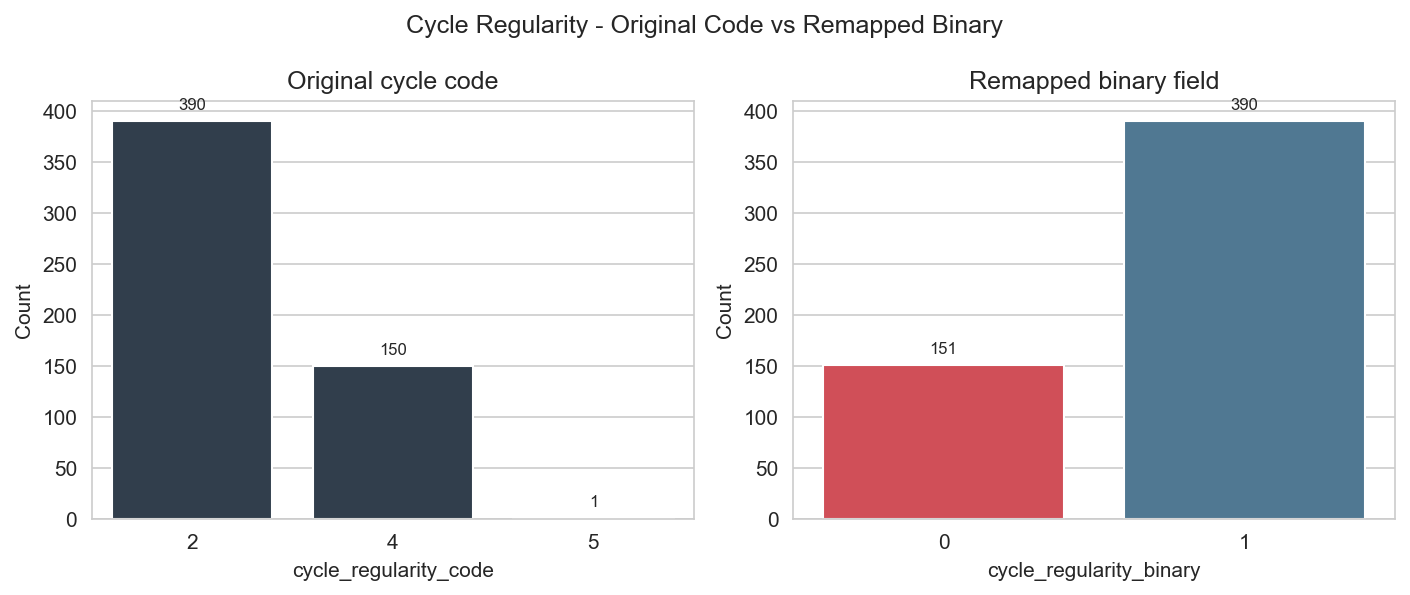

In [76]:
# Plotting the remap result is making the original code distribution and the new binary distribution easy to compare.
original_counts = df["cycle_regularity_code"].value_counts().sort_index().reset_index()
original_counts.columns = ["value", "count"]
binary_counts = df["cycle_regularity_binary"].value_counts().sort_index().reset_index()
binary_counts.columns = ["value", "count"]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.0))
sns.barplot(data=original_counts, x="value", y="count", color=COLORS["neutral"], ax=axes[0])
axes[0].set_title("Original cycle code")
axes[0].set_xlabel("cycle_regularity_code")
axes[0].set_ylabel("Count")
annotate_bars(axes[0])

sns.barplot(
    data=binary_counts,
    x="value",
    y="count",
    palette=[COLORS["pcos_pos"], COLORS["pcos_neg"]],
    ax=axes[1],
)
axes[1].set_title("Remapped binary field")
axes[1].set_xlabel("cycle_regularity_binary")
axes[1].set_ylabel("Count")
annotate_bars(axes[1])

fig.suptitle("Cycle Regularity - Original Code vs Remapped Binary")
fig.tight_layout()
output_path = save_figure(fig, "02_cycle_regularity_remap.png")
print(f"Saved figure to: {output_path}")
plt.show()


In [77]:
# Printing cycle regularity by PCOS status is showing how the new binary field behaves against the target before modelling starts.
cycle_by_target_counts = pd.crosstab(
    df["cycle_regularity_binary"],
    df[TARGET],
    rownames=["cycle_regularity_binary"],
    colnames=["pcos_y_n"],
)
cycle_by_target_pct = pd.crosstab(
    df["cycle_regularity_binary"],
    df[TARGET],
    rownames=["cycle_regularity_binary"],
    colnames=["pcos_y_n"],
    normalize="columns",
).mul(100).round(2)

print("Counts:")
print(cycle_by_target_counts)
print()
print("Column percentages:")
print(cycle_by_target_pct)
print()
irregular_share = (df.loc[df[TARGET] == 1, "cycle_regularity_binary"] == 0).mean() * 100
print(f"PCOS-positive patients with irregular cycles in this dataset: {irregular_share:.2f}%")


Counts:
pcos_y_n                   0   1
cycle_regularity_binary         
0                         56  95
1                        308  82

Column percentages:
pcos_y_n                      0       1
cycle_regularity_binary                
0                       15.3800 53.6700
1                       84.6200 46.3300

PCOS-positive patients with irregular cycles in this dataset: 53.67%


## Section 4 - Model 1 Feature Definition and Selection

This section is defining the non-invasive clinical screening model. The model is using routine clinical information that can be collected without hormonal testing or ultrasound.

| Feature Name | Column Name | Clinical Meaning | Type | Inclusion Rationale |
| --- | --- | --- | --- | --- |
| Age | `age_yrs` | Age in years | Continuous | Keeping age is giving basic life-stage context. |
| BMI | `bmi` | Body mass index | Continuous | BMI is tracking body-weight burden linked to PCOS. |
| Cycle regularity | `cycle_regularity_binary` | Regular vs irregular cycle | Binary | Cycle pattern is a key non-invasive PCOS signal. |
| Cycle length | `cycle_length_days` | Recorded cycle-length measure | Continuous | Cycle timing helps capture menstrual disruption. |
| Weight gain | `weight_gain_y_n` | Reported weight gain | Binary | Weight gain often appears in PCOS symptom profiles. |
| Hair growth | `hair_growth_y_n` | Excess hair growth | Binary | This is a visible androgen-related symptom. |
| Skin darkening | `skin_darkening_y_n` | Skin darkening | Binary | This can reflect metabolic change and insulin burden. |
| Hair loss | `hair_loss_y_n` | Hair loss | Binary | This is another visible androgen-related symptom. |
| Pimples | `pimples_y_n` | Pimples or acne | Binary | This supports the androgenic symptom pattern. |
| Fast food | `fast_food_y_n` | Fast-food habit flag | Binary | This gives simple diet-risk context. |
| Regular exercise | `regular_exercise_y_n` | Regular exercise flag | Binary | This gives simple activity context. |
| Systolic BP | `systolic_bp_mmhg` | Systolic blood pressure | Continuous | This keeps routine cardiovascular information in the model. |
| Diastolic BP | `diastolic_bp_mmhg` | Diastolic blood pressure | Continuous | This adds the second blood-pressure component. |
| Waist-hip ratio | `waist_hip_ratio` | Body fat distribution marker | Continuous | This captures central adiposity better than BMI alone. |
| Random blood sugar | `rbs_mg_dl` | Random blood sugar | Continuous | This keeps a routine metabolic burden marker. |


In [78]:
# Defining the Model 1 base feature list is locking the non-invasive clinical contract used throughout the rest of the notebook.
MODEL1_BASE = [
    "age_yrs",
    "bmi",
    "cycle_regularity_binary",
    "cycle_length_days",
    "weight_gain_y_n",
    "hair_growth_y_n",
    "skin_darkening_y_n",
    "hair_loss_y_n",
    "pimples_y_n",
    "fast_food_y_n",
    "regular_exercise_y_n",
    "systolic_bp_mmhg",
    "diastolic_bp_mmhg",
    "waist_hip_ratio",
    "rbs_mg_dl",
]

print("Model 1 feature contract check:")
for feature in MODEL1_BASE:
    exists = feature in df.columns
    status = "PASS" if exists else "FAIL"
    print(f"{status:4} - {feature}")

missing_features = [feature for feature in MODEL1_BASE if feature not in df.columns]
assert not missing_features, f"Missing Model 1 features: {missing_features}"


Model 1 feature contract check:
PASS - age_yrs
PASS - bmi
PASS - cycle_regularity_binary
PASS - cycle_length_days
PASS - weight_gain_y_n
PASS - hair_growth_y_n
PASS - skin_darkening_y_n
PASS - hair_loss_y_n
PASS - pimples_y_n
PASS - fast_food_y_n
PASS - regular_exercise_y_n
PASS - systolic_bp_mmhg
PASS - diastolic_bp_mmhg
PASS - waist_hip_ratio
PASS - rbs_mg_dl


In [79]:
# Auditing missing values for the Model 1 base features is checking whether any fields still need attention before feature ranking.
model1_missing_table = build_missing_table(df, MODEL1_BASE)
print(model1_missing_table)


                    feature  missing_count  missing_pct
0                   age_yrs              0       0.0000
1                       bmi              0       0.0000
2   cycle_regularity_binary              0       0.0000
3         cycle_length_days              0       0.0000
4           weight_gain_y_n              0       0.0000
5           hair_growth_y_n              0       0.0000
6        skin_darkening_y_n              0       0.0000
7             hair_loss_y_n              0       0.0000
8               pimples_y_n              0       0.0000
9             fast_food_y_n              0       0.0000
10     regular_exercise_y_n              0       0.0000
11         systolic_bp_mmhg              0       0.0000
12        diastolic_bp_mmhg              0       0.0000
13          waist_hip_ratio              0       0.0000
14                rbs_mg_dl              0       0.0000


## Model 1 Feature Selection - Three-Method Approach

This section is using three simple ranking methods to understand which non-invasive features carry the strongest signal:

- Mutual Information
- Spearman correlation
- Random Forest importance

These rankings are not being used to automatically drop features. They are being used to document the feature selection reasoning and to flag any weak watch items for later SHAP review.


In [80]:
# Calculating Mutual Information scores is ranking the non-invasive features by how much target information they carry.
X1_raw = df[MODEL1_BASE].copy()
y = df[TARGET].copy()

mi_scores = mutual_info_classif(X1_raw, y, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({
    "feature": MODEL1_BASE,
    "mi_score": mi_scores,
}).sort_values("mi_score", ascending=False).reset_index(drop=True)
mi_df["mi_rank"] = range(1, len(mi_df) + 1)
print(mi_df)


                    feature  mi_score  mi_rank
0        skin_darkening_y_n    0.1386        1
1           hair_growth_y_n    0.0951        2
2           weight_gain_y_n    0.0778        3
3   cycle_regularity_binary    0.0771        4
4         cycle_length_days    0.0712        5
5             fast_food_y_n    0.0600        6
6               pimples_y_n    0.0525        7
7           waist_hip_ratio    0.0299        8
8             hair_loss_y_n    0.0170        9
9                   age_yrs    0.0157       10
10                      bmi    0.0142       11
11     regular_exercise_y_n    0.0040       12
12         systolic_bp_mmhg    0.0000       13
13        diastolic_bp_mmhg    0.0000       14
14                rbs_mg_dl    0.0000       15


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\feature_engineering\03_model1_mutual_information.png


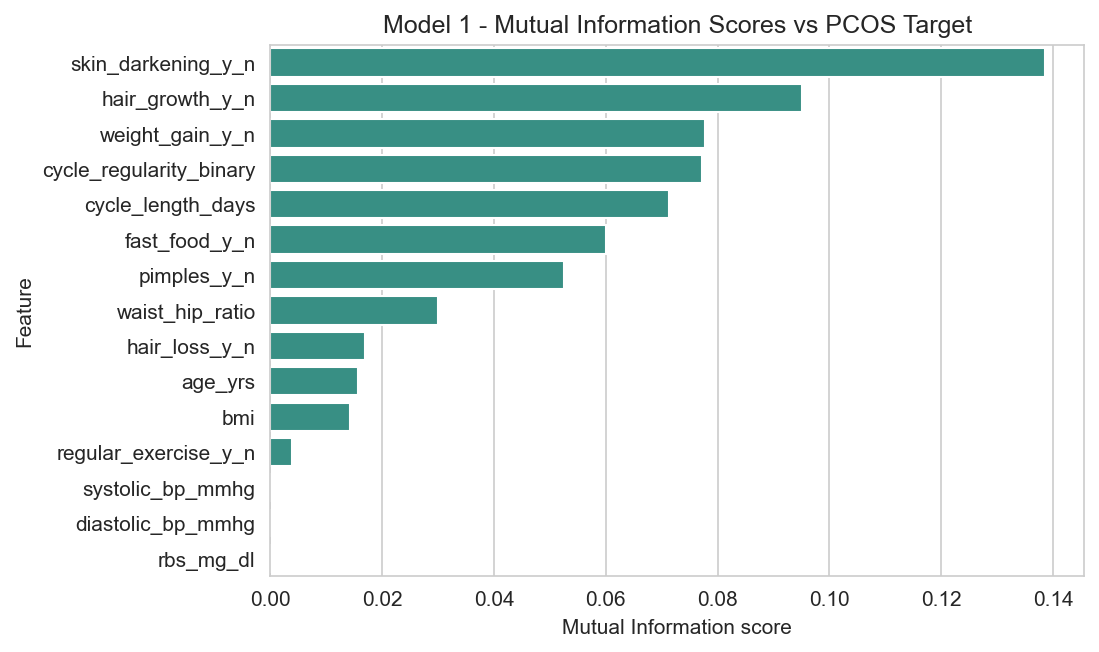

In [81]:
# Plotting the Mutual Information scores is showing the strongest and weakest non-invasive features in a quick visual ranking.
fig, ax = plt.subplots(figsize=(7.0, 4.6))
sns.barplot(data=mi_df, y="feature", x="mi_score", color=COLORS["model1"], ax=ax)
ax.set_title("Model 1 - Mutual Information Scores vs PCOS Target")
ax.set_xlabel("Mutual Information score")
ax.set_ylabel("Feature")
output_path = save_figure(fig, "03_model1_mutual_information.png")
print(f"Saved figure to: {output_path}")
plt.show()


In [82]:
# Calculating Spearman correlation is ranking the non-invasive features by monotonic association with the PCOS target.
spearman_rows = []
for feature in MODEL1_BASE:
    rho, p_value = stats.spearmanr(df[feature], y)
    spearman_rows.append({
        "feature": feature,
        "spearman_rho": rho,
        "p_value": p_value,
        "abs_rho": abs(rho),
        "significant": p_value < 0.05,
    })

spearman_df = (
    pd.DataFrame(spearman_rows)
    .sort_values("abs_rho", ascending=False)
    .reset_index(drop=True)
)
spearman_df["spearman_rank"] = range(1, len(spearman_df) + 1)
print(spearman_df)


                    feature  spearman_rho  p_value  abs_rho  significant  \
0        skin_darkening_y_n        0.4757   0.0000   0.4757         True   
1           hair_growth_y_n        0.4647   0.0000   0.4647         True   
2           weight_gain_y_n        0.4410   0.0000   0.4410         True   
3   cycle_regularity_binary       -0.4005   0.0000   0.4005         True   
4             fast_food_y_n        0.3762   0.0000   0.3762         True   
5               pimples_y_n        0.2861   0.0000   0.2861         True   
6         cycle_length_days       -0.2534   0.0000   0.2534         True   
7                       bmi        0.1962   0.0000   0.1962         True   
8                   age_yrs       -0.1853   0.0000   0.1853         True   
9             hair_loss_y_n        0.1729   0.0001   0.1729         True   
10     regular_exercise_y_n        0.0653   0.1291   0.0653        False   
11                rbs_mg_dl        0.0406   0.3454   0.0406        False   
12        di

Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\feature_engineering\04_model1_spearman_correlation.png


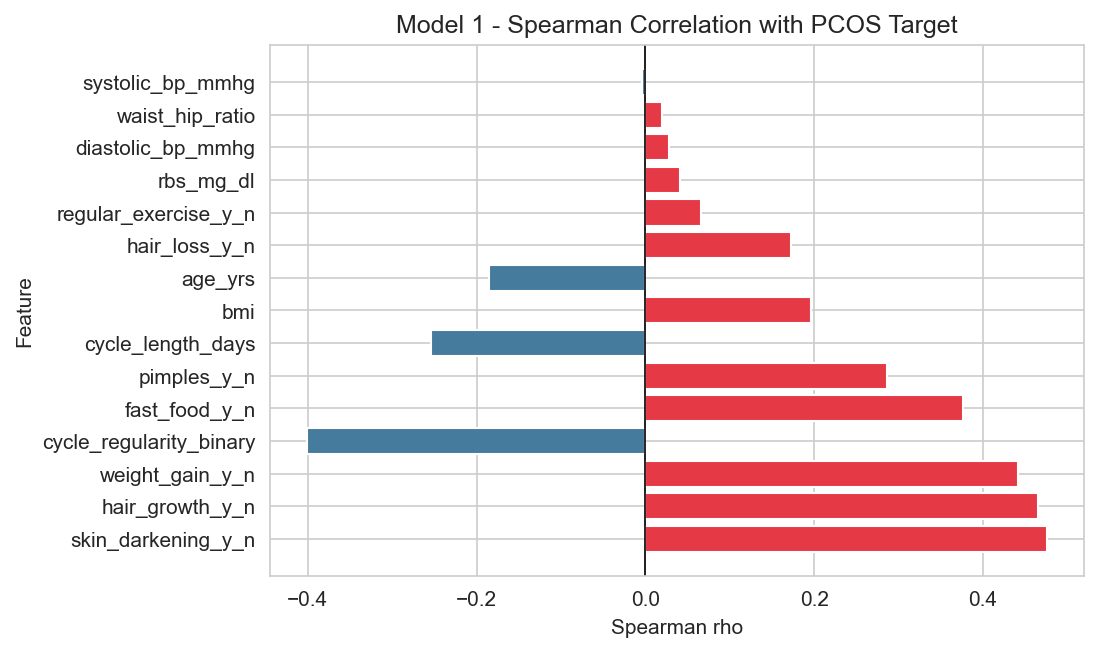

In [83]:
# Plotting Spearman correlation is showing both the direction and the strength of the feature-target relationship.
spearman_plot_df = spearman_df.copy()
spearman_plot_df["direction_color"] = np.where(
    spearman_plot_df["spearman_rho"] >= 0,
    COLORS["pcos_pos"],
    COLORS["pcos_neg"],
)

fig, ax = plt.subplots(figsize=(7.0, 4.6))
ax.barh(
    spearman_plot_df["feature"],
    spearman_plot_df["spearman_rho"],
    color=spearman_plot_df["direction_color"],
)
ax.set_title("Model 1 - Spearman Correlation with PCOS Target")
ax.set_xlabel("Spearman rho")
ax.set_ylabel("Feature")
ax.axvline(0, color="black", linewidth=0.8)
output_path = save_figure(fig, "04_model1_spearman_correlation.png")
print(f"Saved figure to: {output_path}")
plt.show()


In [84]:
# Calculating Random Forest importances is ranking the non-invasive features by ensemble-based predictive usefulness.
rf_selector = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)
rf_selector.fit(X1_raw, y)

rf_df = pd.DataFrame({
    "feature": MODEL1_BASE,
    "importance": rf_selector.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)
rf_df["rf_rank"] = range(1, len(rf_df) + 1)
print(rf_df)


                    feature  importance  rf_rank
0        skin_darkening_y_n      0.1071        1
1           hair_growth_y_n      0.1035        2
2                       bmi      0.1001        3
3           waist_hip_ratio      0.0998        4
4                   age_yrs      0.0910        5
5           weight_gain_y_n      0.0835        6
6         cycle_length_days      0.0796        7
7                 rbs_mg_dl      0.0777        8
8   cycle_regularity_binary      0.0628        9
9             fast_food_y_n      0.0564       10
10              pimples_y_n      0.0424       11
11         systolic_bp_mmhg      0.0282       12
12     regular_exercise_y_n      0.0278       13
13            hair_loss_y_n      0.0215       14
14        diastolic_bp_mmhg      0.0188       15


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\feature_engineering\05_model1_rf_importances.png


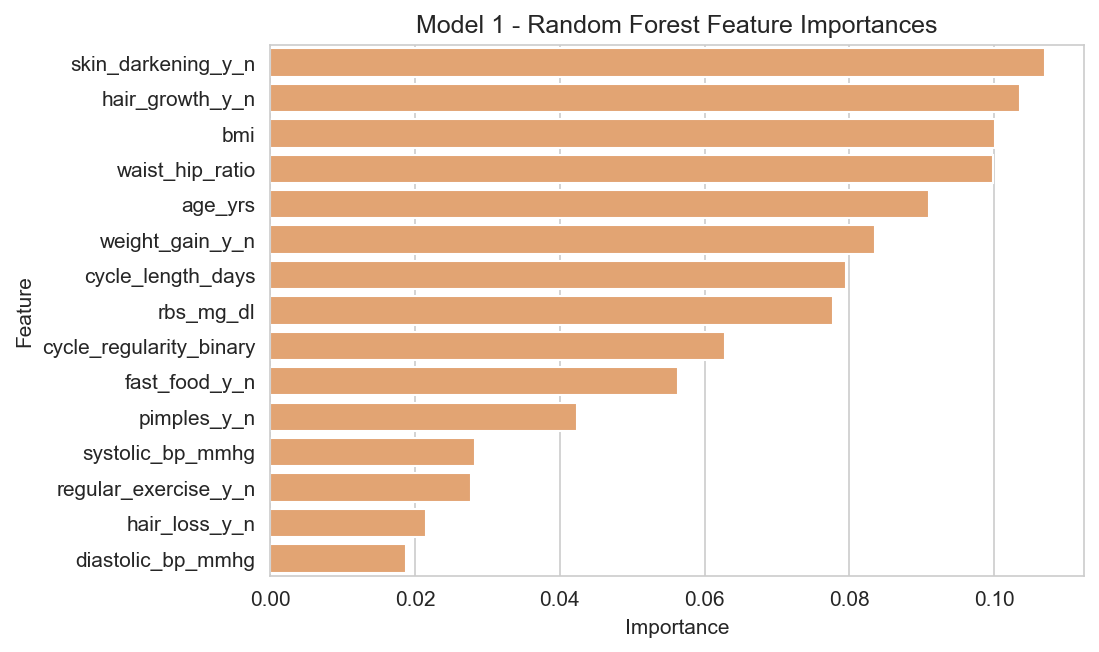

In [85]:
# Plotting Random Forest importances is showing how the ensemble model is weighting the non-invasive features.
fig, ax = plt.subplots(figsize=(7.0, 4.6))
sns.barplot(data=rf_df, y="feature", x="importance", color=COLORS["highlight"], ax=ax)
ax.set_title("Model 1 - Random Forest Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
output_path = save_figure(fig, "05_model1_rf_importances.png")
print(f"Saved figure to: {output_path}")
plt.show()


In [86]:
# Building the consensus table is combining the three ranking methods into one feature-selection summary view.
consensus_df = (
    mi_df[["feature", "mi_score", "mi_rank"]]
    .merge(
        spearman_df[["feature", "spearman_rho", "p_value", "spearman_rank"]],
        on="feature",
    )
    .merge(
        rf_df[["feature", "importance", "rf_rank"]],
        on="feature",
    )
)

consensus_df["consensus_score"] = consensus_df[["mi_rank", "spearman_rank", "rf_rank"]].mean(axis=1)
consensus_df = consensus_df.sort_values("consensus_score", ascending=True).reset_index(drop=True)

bottom_three_mi = set(mi_df.tail(3)["feature"])
bottom_three_spearman = set(spearman_df.tail(3)["feature"])
bottom_three_rf = set(rf_df.tail(3)["feature"])
consensus_df["bottom_all_three"] = consensus_df["feature"].apply(
    lambda feature: feature in bottom_three_mi and feature in bottom_three_spearman and feature in bottom_three_rf
)

watch_features = consensus_df.loc[consensus_df["bottom_all_three"], "feature"].tolist()

print(consensus_df)
print()
print("Watch features for later SHAP review:")
print(watch_features if watch_features else "None")


                    feature  mi_score  mi_rank  spearman_rho  p_value  \
0        skin_darkening_y_n    0.1386        1        0.4757   0.0000   
1           hair_growth_y_n    0.0951        2        0.4647   0.0000   
2           weight_gain_y_n    0.0778        3        0.4410   0.0000   
3   cycle_regularity_binary    0.0771        4       -0.4005   0.0000   
4         cycle_length_days    0.0712        5       -0.2534   0.0000   
5             fast_food_y_n    0.0600        6        0.3762   0.0000   
6                       bmi    0.0142       11        0.1962   0.0000   
7               pimples_y_n    0.0525        7        0.2861   0.0000   
8                   age_yrs    0.0157       10       -0.1853   0.0000   
9           waist_hip_ratio    0.0299        8        0.0192   0.6554   
10            hair_loss_y_n    0.0170        9        0.1729   0.0001   
11                rbs_mg_dl    0.0000       15        0.0406   0.3454   
12     regular_exercise_y_n    0.0040       12     

Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\feature_engineering\06_model1_feature_consensus.png


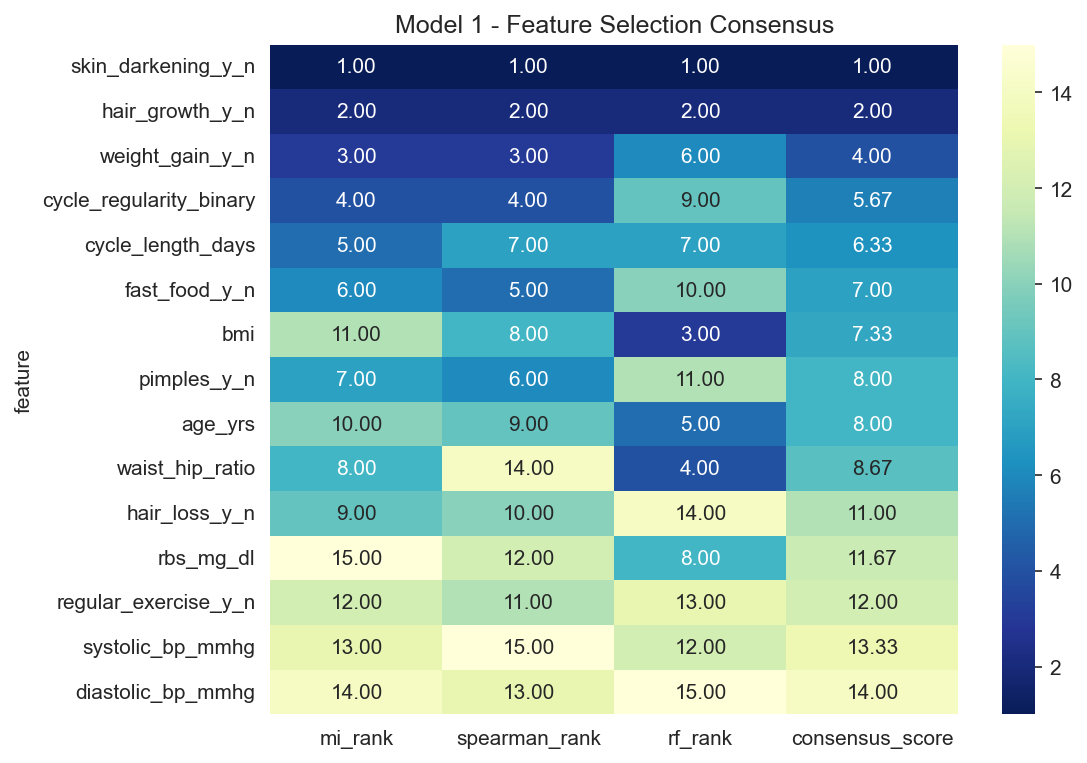

In [87]:
# Plotting the consensus heatmap is showing where the ranking methods agree or disagree across the Model 1 features.
consensus_heatmap_df = consensus_df.set_index("feature")[["mi_rank", "spearman_rank", "rf_rank", "consensus_score"]]
fig, ax = plt.subplots(figsize=(7.4, 5.8))
sns.heatmap(consensus_heatmap_df, annot=True, cmap="YlGnBu_r", fmt=".2f", ax=ax)
ax.set_title("Model 1 - Feature Selection Consensus")
output_path = save_figure(fig, "06_model1_feature_consensus.png")
print(f"Saved figure to: {output_path}")
plt.show()


## Model 1 Feature Retention Decision

All 15 non-invasive base features are being retained.

This decision is being made for three reasons:

1. The main thesis goal is high-recall screening with routine clinical data.
2. Ensemble models can still gain from features that look weak on their own but become useful in interaction with other variables.
3. Later SHAP analysis will give a stronger explanation of final model behaviour than pre-model feature dropping alone.

Any features flagged in the printed consensus table are being treated as watch items for later SHAP review, not as automatic drop candidates in this notebook.


## Section 5 - Feature Engineering for Both Models

This section is creating four engineered features from existing non-invasive columns. These derived features are coming from patterns already seen in the EDA notebooks, and they are being used only where the source inputs already exist in the clinical dataset.


In [88]:
# Deriving symptom_burden is combining the five visible symptom flags into one simple burden score.
symptom_cols = [
    "weight_gain_y_n",
    "hair_growth_y_n",
    "skin_darkening_y_n",
    "hair_loss_y_n",
    "pimples_y_n",
]
df["symptom_burden"] = df[symptom_cols].sum(axis=1)

print("Symptom burden counts:")
print(df["symptom_burden"].value_counts().sort_index())
print()
print("Mean symptom burden by PCOS status:")
print(df.groupby(TARGET)["symptom_burden"].mean().round(4))


Symptom burden counts:
symptom_burden
0    129
1     95
2    140
3     88
4     56
5     33
Name: count, dtype: int64

Mean symptom burden by PCOS status:
pcos_y_n
0   1.2940
1   3.1469
Name: symptom_burden, dtype: float64


In [89]:
# Deriving bmi_category is converting BMI into standard weight-status groups.
def bmi_to_category(bmi: float) -> int:
    if bmi < 18.5:
        return 0
    if bmi < 25:
        return 1
    if bmi < 30:
        return 2
    return 3

df["bmi_category"] = df["bmi"].apply(bmi_to_category)

print("BMI category counts:")
print(df["bmi_category"].value_counts().sort_index())
print()
print("BMI category by PCOS status:")
print(pd.crosstab(df["bmi_category"], df[TARGET]))
print()
overweight_or_obese = (
    df.loc[df[TARGET] == 1, "bmi_category"].isin([2, 3]).mean() * 100
)
print(f"PCOS-positive patients who are overweight or obese: {overweight_or_obese:.2f}%")


BMI category counts:
bmi_category
0     35
1    278
2    185
3     43
Name: count, dtype: int64

BMI category by PCOS status:
pcos_y_n        0   1
bmi_category         
0              25  10
1             205  73
2             115  70
3              19  24

PCOS-positive patients who are overweight or obese: 53.11%


In [90]:
# Deriving bp_elevated_flag is marking patients whose systolic or diastolic pressure reaches an elevated range.
df["bp_elevated_flag"] = (
    (df["systolic_bp_mmhg"] >= 130) |
    (df["diastolic_bp_mmhg"] >= 80)
).astype(int)

print("bp_elevated_flag counts:")
print(df["bp_elevated_flag"].value_counts().sort_index())
print()
bp_crosstab = pd.crosstab(df["bp_elevated_flag"], df[TARGET])
print("bp_elevated_flag by PCOS status:")
print(bp_crosstab)
print()
elevated_share = (df.loc[df[TARGET] == 1, "bp_elevated_flag"] == 1).mean() * 100
print(f"PCOS-positive patients with elevated blood pressure: {elevated_share:.2f}%")


bp_elevated_flag counts:
bp_elevated_flag
0    159
1    382
Name: count, dtype: int64

bp_elevated_flag by PCOS status:
pcos_y_n            0    1
bp_elevated_flag          
0                 110   49
1                 254  128

PCOS-positive patients with elevated blood pressure: 72.32%


In [91]:
# Deriving lifestyle_risk is combining fast-food exposure and low exercise into a small lifestyle score.
df["lifestyle_risk"] = df["fast_food_y_n"] + (1 - df["regular_exercise_y_n"])

print("lifestyle_risk counts:")
print(df["lifestyle_risk"].value_counts().sort_index())
print()
print("Mean lifestyle_risk by PCOS status:")
print(df.groupby(TARGET)["lifestyle_risk"].mean().round(4))


lifestyle_risk counts:
lifestyle_risk
0     57
1    282
2    202
Name: count, dtype: int64

Mean lifestyle_risk by PCOS status:
pcos_y_n
0   1.1566
1   1.4972
Name: lifestyle_risk, dtype: float64


In [92]:
# Verifying the engineered features is confirming that all four derived columns are fully usable before modelling preparation continues.
engineered_features = ["symptom_burden", "bmi_category", "bp_elevated_flag", "lifestyle_risk"]
engineered_missing = build_missing_table(df, engineered_features)
print(engineered_missing)
assert engineered_missing["missing_count"].sum() == 0, "Engineered features still contain missing values."
print()
print("All engineered features contain zero missing values.")


            feature  missing_count  missing_pct
0    symptom_burden              0       0.0000
1      bmi_category              0       0.0000
2  bp_elevated_flag              0       0.0000
3    lifestyle_risk              0       0.0000

All engineered features contain zero missing values.


In [93]:
# Printing the engineered-feature tables is documenting the exact grouped summaries behind the engineered-feature overview figure.
symptom_table = pd.crosstab(df["symptom_burden"], df[TARGET])
bmi_category_table = pd.crosstab(df["bmi_category"], df[TARGET])
bp_flag_table = (
    df.groupby(TARGET)["bp_elevated_flag"]
    .mean()
    .mul(100)
    .reset_index(name="elevated_bp_pct")
)
lifestyle_table = pd.crosstab(df["lifestyle_risk"], df[TARGET])

print("Symptom burden by target:")
print(symptom_table)
print()
print("BMI category by target:")
print(bmi_category_table)
print()
print("Elevated blood pressure prevalence by target:")
print(bp_flag_table)
print()
print("Lifestyle risk by target:")
print(lifestyle_table)


Symptom burden by target:
pcos_y_n          0   1
symptom_burden         
0               119  10
1                81  14
2               119  21
3                34  54
4                 5  51
5                 6  27

BMI category by target:
pcos_y_n        0   1
bmi_category         
0              25  10
1             205  73
2             115  70
3              19  24

Elevated blood pressure prevalence by target:
   pcos_y_n  elevated_bp_pct
0         0          69.7802
1         1          72.3164

Lifestyle risk by target:
pcos_y_n          0    1
lifestyle_risk          
0                42   15
1               223   59
2                99  103


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\feature_engineering\07_model1_engineered_features.png


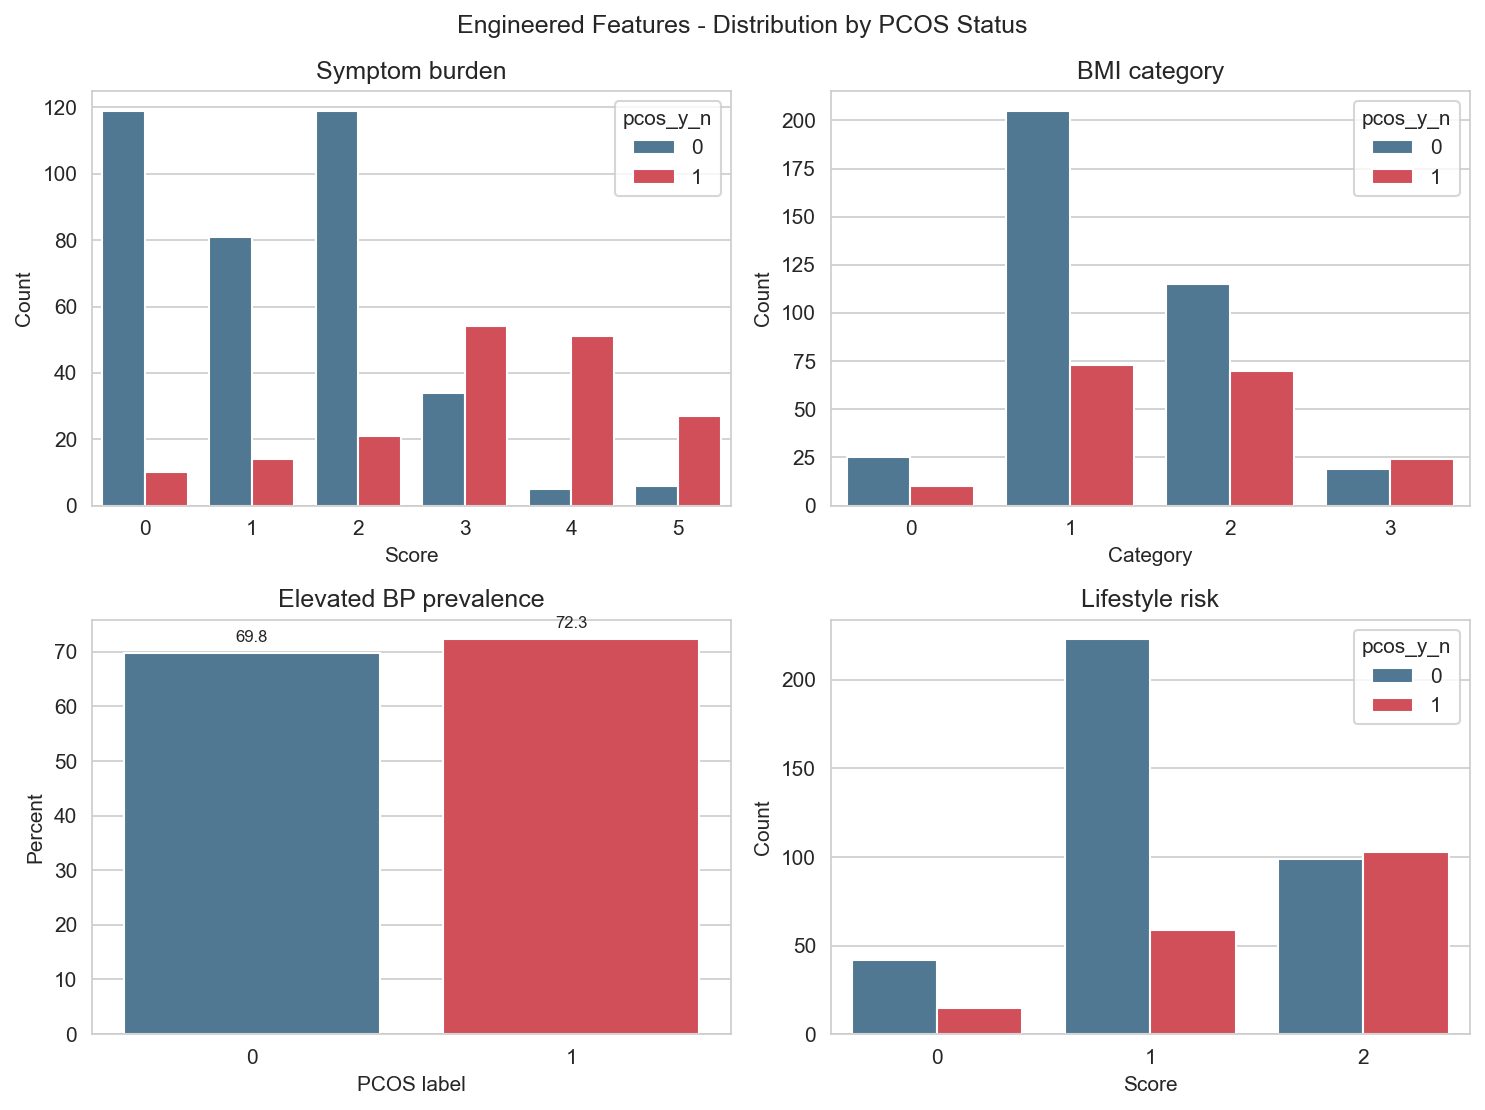

In [94]:
# Plotting the engineered-feature overview is showing how the four derived variables differ by PCOS status.
fig, axes = plt.subplots(2, 2, figsize=(10.0, 7.5))

sns.countplot(data=df, x="symptom_burden", hue=TARGET, palette=[COLORS["pcos_neg"], COLORS["pcos_pos"]], ax=axes[0, 0])
axes[0, 0].set_title("Symptom burden")
axes[0, 0].set_xlabel("Score")
axes[0, 0].set_ylabel("Count")

sns.countplot(data=df, x="bmi_category", hue=TARGET, palette=[COLORS["pcos_neg"], COLORS["pcos_pos"]], ax=axes[0, 1])
axes[0, 1].set_title("BMI category")
axes[0, 1].set_xlabel("Category")
axes[0, 1].set_ylabel("Count")

sns.barplot(data=bp_flag_table, x=TARGET, y="elevated_bp_pct", palette=[COLORS["pcos_neg"], COLORS["pcos_pos"]], ax=axes[1, 0])
axes[1, 0].set_title("Elevated BP prevalence")
axes[1, 0].set_xlabel("PCOS label")
axes[1, 0].set_ylabel("Percent")
annotate_bars(axes[1, 0], total=None, decimals=1)

sns.countplot(data=df, x="lifestyle_risk", hue=TARGET, palette=[COLORS["pcos_neg"], COLORS["pcos_pos"]], ax=axes[1, 1])
axes[1, 1].set_title("Lifestyle risk")
axes[1, 1].set_xlabel("Score")
axes[1, 1].set_ylabel("Count")

for ax in axes.flat:
    if ax.legend_ is not None:
        ax.legend(title="pcos_y_n")

fig.suptitle("Engineered Features - Distribution by PCOS Status")
fig.tight_layout()
output_path = save_figure(fig, "07_model1_engineered_features.png")
print(f"Saved figure to: {output_path}")
plt.show()


## Section 6 - Finalising Feature Lists for Both Models

This section is locking the final feature contracts for the two models.

### Model 2 Invasive Contract
| Feature Name | Column Name | Clinical Meaning | Inclusion Rationale |
| --- | --- | --- | --- |
| AMH | `amh_ng_ml` | Anti-Mullerian hormone | Hormonal marker of ovarian reserve. |
| FSH | `fsh_miu_ml` | Follicle-stimulating hormone | Core reproductive hormone. |
| LH | `lh_miu_ml` | Luteinizing hormone | Core reproductive hormone. |
| FSH/LH ratio | `fsh_lh_ratio` | Hormonal balance ratio | Common PCOS-related endocrine summary feature. |
| TSH | `tsh_miu_l` | Thyroid-stimulating hormone | Supports endocrine context. |
| PRL | `prl_ng_ml` | Prolactin | Supports endocrine context. |
| Vitamin D3 | `vit_d3_ng_ml` | Vitamin D3 level | Adds systemic clinical context. |
| Progesterone | `prg_ng_ml` | Progesterone level | Adds reproductive hormone context. |
| Beta-HCG I | `beta_hcg_i_miu_ml` | Beta-HCG test 1 | Retained as part of the invasive laboratory profile. |
| Beta-HCG II | `beta_hcg_ii_miu_ml` | Beta-HCG test 2 | Retained as part of the invasive laboratory profile. |
| Left follicle count | `follicle_no_left` | Follicle count in left ovary | Ultrasound-derived ovarian burden feature. |
| Right follicle count | `follicle_no_right` | Follicle count in right ovary | Ultrasound-derived ovarian burden feature. |
| Left follicle size | `avg_follicle_size_left_mm` | Average left follicle size | Ultrasound-derived ovarian feature. |
| Right follicle size | `avg_follicle_size_right_mm` | Average right follicle size | Ultrasound-derived ovarian feature. |
| Endometrium | `endometrium_mm` | Endometrium thickness | Ultrasound-derived reproductive feature. |


In [95]:
# Defining the final feature lists is locking the two modelling contracts used by all downstream notebooks.
MODEL1_FEATURES = MODEL1_BASE + [
    "symptom_burden",
    "bmi_category",
    "bp_elevated_flag",
    "lifestyle_risk",
]

MODEL2_FEATURES = [
    "amh_ng_ml",
    "fsh_miu_ml",
    "lh_miu_ml",
    "fsh_lh_ratio",
    "tsh_miu_l",
    "prl_ng_ml",
    "vit_d3_ng_ml",
    "prg_ng_ml",
    "beta_hcg_i_miu_ml",
    "beta_hcg_ii_miu_ml",
    "follicle_no_left",
    "follicle_no_right",
    "avg_follicle_size_left_mm",
    "avg_follicle_size_right_mm",
    "endometrium_mm",
]

print("Model 1 final features:")
print(MODEL1_FEATURES)
print(f"Model 1 feature count: {len(MODEL1_FEATURES)}")
print()
print("Model 2 final features:")
print(MODEL2_FEATURES)
print(f"Model 2 feature count: {len(MODEL2_FEATURES)}")

assert len(MODEL1_FEATURES) == 19, "Model 1 feature count should be 19."
assert len(MODEL2_FEATURES) == 15, "Model 2 feature count should be 15."
assert len(MODEL1_FEATURES) == len(set(MODEL1_FEATURES)), "Model 1 contains duplicate feature names."
assert len(MODEL2_FEATURES) == len(set(MODEL2_FEATURES)), "Model 2 contains duplicate feature names."


Model 1 final features:
['age_yrs', 'bmi', 'cycle_regularity_binary', 'cycle_length_days', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n', 'fast_food_y_n', 'regular_exercise_y_n', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'waist_hip_ratio', 'rbs_mg_dl', 'symptom_burden', 'bmi_category', 'bp_elevated_flag', 'lifestyle_risk']
Model 1 feature count: 19

Model 2 final features:
['amh_ng_ml', 'fsh_miu_ml', 'lh_miu_ml', 'fsh_lh_ratio', 'tsh_miu_l', 'prl_ng_ml', 'vit_d3_ng_ml', 'prg_ng_ml', 'beta_hcg_i_miu_ml', 'beta_hcg_ii_miu_ml', 'follicle_no_left', 'follicle_no_right', 'avg_follicle_size_left_mm', 'avg_follicle_size_right_mm', 'endometrium_mm']
Model 2 feature count: 15


In [96]:
# Checking the invasive feature contract is confirming that every Model 2 feature exists in the cleaned clinical dataset.
print("Model 2 feature contract check:")
for feature in MODEL2_FEATURES:
    exists = feature in df.columns
    status = "PASS" if exists else "FAIL"
    print(f"{status:4} - {feature}")

missing_model2_features = [feature for feature in MODEL2_FEATURES if feature not in df.columns]
assert not missing_model2_features, f"Missing Model 2 features: {missing_model2_features}"


Model 2 feature contract check:
PASS - amh_ng_ml
PASS - fsh_miu_ml
PASS - lh_miu_ml
PASS - fsh_lh_ratio
PASS - tsh_miu_l
PASS - prl_ng_ml
PASS - vit_d3_ng_ml
PASS - prg_ng_ml
PASS - beta_hcg_i_miu_ml
PASS - beta_hcg_ii_miu_ml
PASS - follicle_no_left
PASS - follicle_no_right
PASS - avg_follicle_size_left_mm
PASS - avg_follicle_size_right_mm
PASS - endometrium_mm


In [97]:
# Auditing the invasive features is checking whether any laboratory or ultrasound fields still contain missing values.
model2_missing_table = build_missing_table(df, MODEL2_FEATURES)
print(model2_missing_table)


                       feature  missing_count  missing_pct
0                    amh_ng_ml              0       0.0000
1                   fsh_miu_ml              0       0.0000
2                    lh_miu_ml              0       0.0000
3                 fsh_lh_ratio              0       0.0000
4                    tsh_miu_l              0       0.0000
5                    prl_ng_ml              0       0.0000
6                 vit_d3_ng_ml              0       0.0000
7                    prg_ng_ml              0       0.0000
8            beta_hcg_i_miu_ml              0       0.0000
9           beta_hcg_ii_miu_ml              0       0.0000
10            follicle_no_left              0       0.0000
11           follicle_no_right              0       0.0000
12   avg_follicle_size_left_mm              0       0.0000
13  avg_follicle_size_right_mm              0       0.0000
14              endometrium_mm              0       0.0000


In [98]:
# Printing the invasive overview table is documenting the grouped values behind the Model 2 overview figure.
invasive_overview_df = (
    df.groupby(TARGET)[MODEL2_FEATURES]
    .agg(["mean", "median"])
    .round(4)
)
print(invasive_overview_df)

invasive_smd_rows = []
for feature in MODEL2_FEATURES:
    negative_values = df.loc[df[TARGET] == 0, feature]
    positive_values = df.loc[df[TARGET] == 1, feature]
    mean_neg = negative_values.mean()
    mean_pos = positive_values.mean()
    pooled_sd = np.sqrt((negative_values.var(ddof=1) + positive_values.var(ddof=1)) / 2)
    smd = 0.0 if pooled_sd == 0 else (mean_pos - mean_neg) / pooled_sd
    invasive_smd_rows.append({
        "feature": feature,
        "mean_pcos_neg": mean_neg,
        "mean_pcos_pos": mean_pos,
        "standardized_mean_difference": smd,
        "abs_smd": abs(smd),
    })

invasive_summary_df = (
    pd.DataFrame(invasive_smd_rows)
    .sort_values("abs_smd", ascending=False)
    .reset_index(drop=True)
)
print()
print("Invasive feature separation summary:")
print(invasive_summary_df)


         amh_ng_ml        fsh_miu_ml        lh_miu_ml        fsh_lh_ratio  \
              mean median       mean median      mean median         mean   
pcos_y_n                                                                    
0           4.5392 3.2100    19.1860 5.0100    2.6127 2.3050       7.6801   
1           7.8446 5.9000     5.1746 4.4800   14.4023 2.2200       5.3104   

                tsh_miu_l        prl_ng_ml         vit_d3_ng_ml          \
         median      mean median      mean  median         mean  median   
pcos_y_n                                                                  
0        2.3636    3.0078 2.1650   24.2679 21.1650      29.2950 26.3000   
1        2.0360    2.9267 2.3100   24.4318 22.9000      92.3226 25.4500   

         prg_ng_ml        beta_hcg_i_miu_ml         beta_hcg_ii_miu_ml         \
              mean median              mean  median               mean median   
pcos_y_n                                                                    

Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\feature_engineering\08_model2_invasive_overview.png


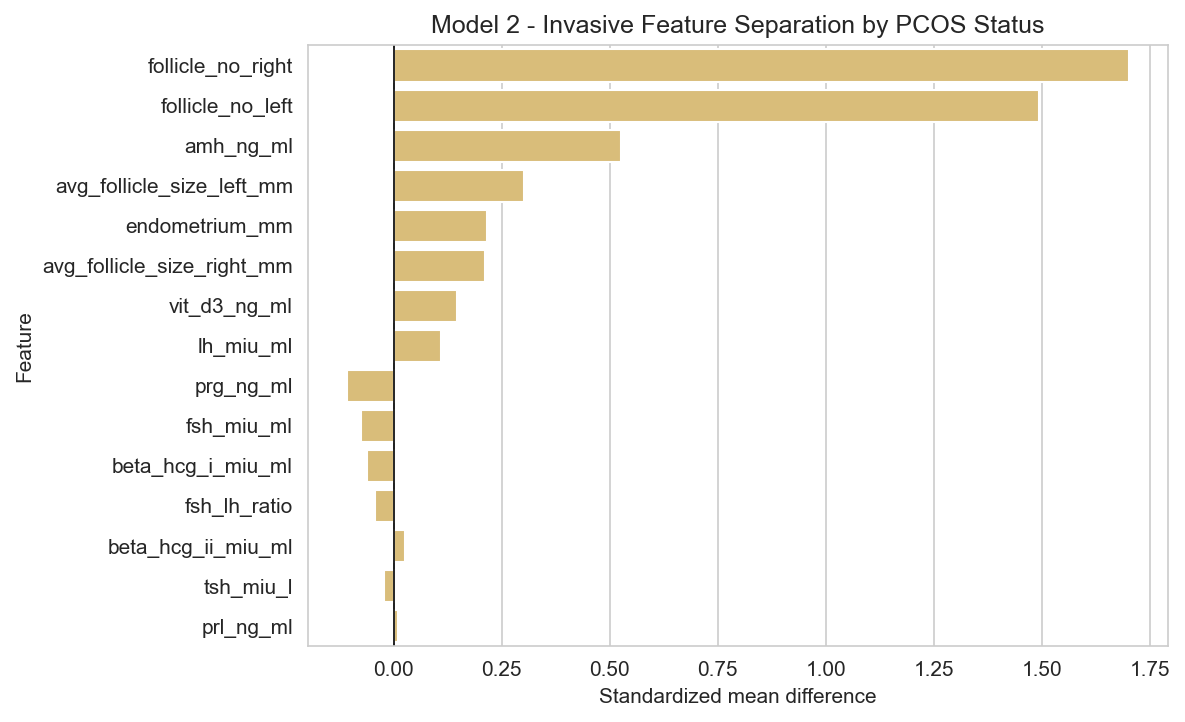

In [99]:
# Plotting the invasive overview is showing which invasive features separate the PCOS groups most strongly.
fig, ax = plt.subplots(figsize=(7.4, 5.2))
sns.barplot(
    data=invasive_summary_df,
    y="feature",
    x="standardized_mean_difference",
    color=COLORS["model2"],
    ax=ax,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Model 2 - Invasive Feature Separation by PCOS Status")
ax.set_xlabel("Standardized mean difference")
ax.set_ylabel("Feature")
output_path = save_figure(fig, "08_model2_invasive_overview.png")
print(f"Saved figure to: {output_path}")
plt.show()


In [100]:
# Printing the feature-count comparison table is documenting the exact counts behind the feature-architecture comparison plot.
feature_count_summary = pd.DataFrame({
    "model": ["Model 1", "Model 2"],
    "base_non_invasive": [15, 0],
    "engineered_non_invasive": [4, 0],
    "invasive_features": [0, 15],
    "total_features": [len(MODEL1_FEATURES), len(MODEL2_FEATURES)],
})
print(feature_count_summary)


     model  base_non_invasive  engineered_non_invasive  invasive_features  \
0  Model 1                 15                        4                  0   
1  Model 2                  0                        0                 15   

   total_features  
0              19  
1              15  


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\feature_engineering\12_feature_count_comparison.png


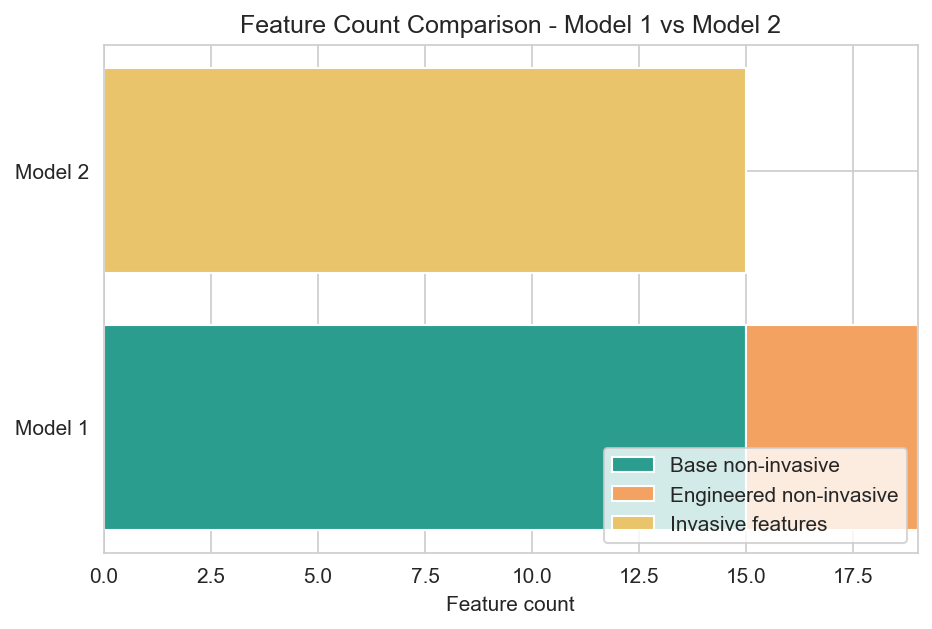

In [101]:
# Plotting the feature-count comparison is showing the structure of the two model contracts side by side.
fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.barh(
    feature_count_summary["model"],
    feature_count_summary["base_non_invasive"],
    color=COLORS["model1"],
    label="Base non-invasive",
)
ax.barh(
    feature_count_summary["model"],
    feature_count_summary["engineered_non_invasive"],
    left=feature_count_summary["base_non_invasive"],
    color=COLORS["highlight"],
    label="Engineered non-invasive",
)
ax.barh(
    feature_count_summary["model"],
    feature_count_summary["invasive_features"],
    left=feature_count_summary["base_non_invasive"] + feature_count_summary["engineered_non_invasive"],
    color=COLORS["model2"],
    label="Invasive features",
)
ax.set_title("Feature Count Comparison - Model 1 vs Model 2")
ax.set_xlabel("Feature count")
ax.set_ylabel("")
ax.legend(loc="lower right")
output_path = save_figure(fig, "12_feature_count_comparison.png")
print(f"Saved figure to: {output_path}")
plt.show()


## Section 7 - Train-Test Split Strategy

This section is creating one shared stratified train-test split from the clinical dataset. The same patient rows are being used for both models. This is making the later performance comparison fair because both models will be judged on the same held-out patients.

The test set is being treated as sealed after the split. It is not being used to fit imputations, fit scalers, or create SMOTE samples.


In [102]:
# Creating the shared row-index split is locking the same patients into the train and test sets for both models.
train_idx, test_idx = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df[TARGET],
)

print(f"Total patients : {len(df)}")
print(f"Training set   : {len(train_idx)} patients ({len(train_idx) / len(df) * 100:.1f}%)")
print(f"Test set       : {len(test_idx)} patients ({len(test_idx) / len(df) * 100:.1f}%)")


Total patients : 541
Training set   : 432 patients (79.9%)
Test set       : 109 patients (20.1%)


In [103]:
# Verifying stratification is confirming that the positive-class percentage stays close between training and test sets.
train_distribution = df.loc[train_idx, TARGET].value_counts().sort_index()
test_distribution = df.loc[test_idx, TARGET].value_counts().sort_index()

print("Training class counts:")
print(train_distribution)
print()
print("Training class percentages:")
print((train_distribution / len(train_idx) * 100).round(2))
print()
print("Test class counts:")
print(test_distribution)
print()
print("Test class percentages:")
print((test_distribution / len(test_idx) * 100).round(2))


Training class counts:
pcos_y_n
0    291
1    141
Name: count, dtype: int64

Training class percentages:
pcos_y_n
0   67.3600
1   32.6400
Name: count, dtype: float64

Test class counts:
pcos_y_n
0    73
1    36
Name: count, dtype: int64

Test class percentages:
pcos_y_n
0   66.9700
1   33.0300
Name: count, dtype: float64


In [104]:
# Creating the raw train and test feature frames is preparing the same patient split for both models before train-only preprocessing.
X1_train_raw = df.loc[train_idx, MODEL1_FEATURES].copy()
X1_test_raw = df.loc[test_idx, MODEL1_FEATURES].copy()

X2_train_raw = df.loc[train_idx, MODEL2_FEATURES].copy()
X2_test_raw = df.loc[test_idx, MODEL2_FEATURES].copy()

y_train = df.loc[train_idx, TARGET].copy()
y_test = df.loc[test_idx, TARGET].copy()

print(f"X1_train_raw shape: {X1_train_raw.shape}")
print(f"X1_test_raw shape : {X1_test_raw.shape}")
print(f"X2_train_raw shape: {X2_train_raw.shape}")
print(f"X2_test_raw shape : {X2_test_raw.shape}")
print(f"y_train shape     : {y_train.shape}")
print(f"y_test shape      : {y_test.shape}")
print()
print("Row-count check:")
print(f"Model 1 and Model 2 training rows match: {len(X1_train_raw) == len(X2_train_raw)}")
print(f"Model 1 and Model 2 test rows match    : {len(X1_test_raw) == len(X2_test_raw)}")


X1_train_raw shape: (432, 19)
X1_test_raw shape : (109, 19)
X2_train_raw shape: (432, 15)
X2_test_raw shape : (109, 15)
y_train shape     : (432,)
y_test shape      : (109,)

Row-count check:
Model 1 and Model 2 training rows match: True
Model 1 and Model 2 test rows match    : True


## Section 8 - Train-Only Imputation and Scaling

This section is learning any needed imputation values from the training rows only and then applying them to the training, test, and later survey-alignment data. This is avoiding data leakage.

The scalers are also being fitted on training data only. Separate scalers are being used because the two models have different feature spaces and different value ranges.


In [105]:
# Building and applying Model 1 fill values is making sure the non-invasive train and test tables are completed using training-only statistics.
MODEL1_BASE_BINARY_COLS = [
    "cycle_regularity_binary",
    "weight_gain_y_n",
    "hair_growth_y_n",
    "skin_darkening_y_n",
    "hair_loss_y_n",
    "pimples_y_n",
    "fast_food_y_n",
    "regular_exercise_y_n",
]
MODEL1_BASE_CONTINUOUS_COLS = [feature for feature in MODEL1_BASE if feature not in MODEL1_BASE_BINARY_COLS]

model1_fill_values = build_fill_values(
    X1_train_raw,
    MODEL1_BASE_BINARY_COLS,
    MODEL1_BASE_CONTINUOUS_COLS,
)
X1_train = apply_fill_values(X1_train_raw, model1_fill_values)
X1_test = apply_fill_values(X1_test_raw, model1_fill_values)

print("Model 1 fill values:")
print(pd.DataFrame({
    "feature": list(model1_fill_values.keys()),
    "fill_value": list(model1_fill_values.values()),
}))


Model 1 fill values:
                    feature  fill_value
0   cycle_regularity_binary      1.0000
1           weight_gain_y_n      0.0000
2           hair_growth_y_n      0.0000
3        skin_darkening_y_n      0.0000
4             hair_loss_y_n      0.0000
5               pimples_y_n      0.0000
6             fast_food_y_n      1.0000
7      regular_exercise_y_n      0.0000
8                   age_yrs     31.0000
9                       bmi     24.1000
10        cycle_length_days      5.0000
11         systolic_bp_mmhg    110.0000
12        diastolic_bp_mmhg     80.0000
13          waist_hip_ratio      0.8947
14                rbs_mg_dl    100.0000


In [106]:
# Printing the Model 1 post-imputation table is confirming that the non-invasive train and test sets contain no missing values after train-only filling.
model1_post_imputation = pd.DataFrame({
    "dataset": ["train", "test"],
    "missing_values": [int(X1_train.isnull().sum().sum()), int(X1_test.isnull().sum().sum())],
})
print(model1_post_imputation)
assert X1_train.isnull().sum().sum() == 0, "Model 1 training data still contains missing values."
assert X1_test.isnull().sum().sum() == 0, "Model 1 test data still contains missing values."


  dataset  missing_values
0   train               0
1    test               0


In [107]:
# Building and applying Model 2 fill values is making sure the invasive train and test tables are completed using training-only medians.
MODEL2_BINARY_COLS: list[str] = []
MODEL2_CONTINUOUS_COLS = MODEL2_FEATURES.copy()

model2_fill_values = build_fill_values(X2_train_raw, MODEL2_BINARY_COLS, MODEL2_CONTINUOUS_COLS)
X2_train = apply_fill_values(X2_train_raw, model2_fill_values)
X2_test = apply_fill_values(X2_test_raw, model2_fill_values)

print("Model 2 fill values:")
print(pd.DataFrame({
    "feature": list(model2_fill_values.keys()),
    "fill_value": list(model2_fill_values.values()),
}))


Model 2 fill values:
                       feature  fill_value
0                    amh_ng_ml      3.7000
1                   fsh_miu_ml      4.8650
2                    lh_miu_ml      2.3000
3                 fsh_lh_ratio      2.2078
4                    tsh_miu_l      2.2750
5                    prl_ng_ml     21.7800
6                 vit_d3_ng_ml     26.3500
7                    prg_ng_ml      0.3200
8            beta_hcg_i_miu_ml     14.9150
9           beta_hcg_ii_miu_ml      1.9900
10            follicle_no_left      5.0000
11           follicle_no_right      6.0000
12   avg_follicle_size_left_mm     15.0000
13  avg_follicle_size_right_mm     16.0000
14              endometrium_mm      8.5000


In [108]:
# Printing the Model 2 post-imputation table is confirming that the invasive train and test sets contain no missing values after train-only filling.
model2_post_imputation = pd.DataFrame({
    "dataset": ["train", "test"],
    "missing_values": [int(X2_train.isnull().sum().sum()), int(X2_test.isnull().sum().sum())],
})
print(model2_post_imputation)
assert X2_train.isnull().sum().sum() == 0, "Model 2 training data still contains missing values."
assert X2_test.isnull().sum().sum() == 0, "Model 2 test data still contains missing values."


  dataset  missing_values
0   train               0
1    test               0


In [109]:
# Fitting and applying the Model 1 scaler is scaling the non-invasive features using training data only.
scaler1 = MinMaxScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

print(f"Model 1 train scaled min: {X1_train_scaled.min():.4f}")
print(f"Model 1 train scaled max: {X1_train_scaled.max():.4f}")
print(f"Model 1 test scaled min : {X1_test_scaled.min():.4f}")
print(f"Model 1 test scaled max : {X1_test_scaled.max():.4f}")

scaler1_path = MODELS_DIR / "scaler_model1.pkl"
joblib.dump(scaler1, scaler1_path)
print(f"Saved scaler to: {scaler1_path}")


Model 1 train scaled min: 0.0000
Model 1 train scaled max: 1.0000
Model 1 test scaled min : -0.0292
Model 1 test scaled max : 1.7576
Saved scaler to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\scaler_model1.pkl


In [110]:
# Fitting and applying the Model 2 scaler is scaling the invasive features using training data only.
scaler2 = MinMaxScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

print(f"Model 2 train scaled min: {X2_train_scaled.min():.4f}")
print(f"Model 2 train scaled max: {X2_train_scaled.max():.4f}")
print(f"Model 2 test scaled min : {X2_test_scaled.min():.4f}")
print(f"Model 2 test scaled max : {X2_test_scaled.max():.4f}")

scaler2_path = MODELS_DIR / "scaler_model2.pkl"
joblib.dump(scaler2, scaler2_path)
print(f"Saved scaler to: {scaler2_path}")


Model 2 train scaled min: 0.0000
Model 2 train scaled max: 1.0000
Model 2 test scaled min : -0.0028
Model 2 test scaled max : 137.6701
Saved scaler to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\scaler_model2.pkl


## Section 9 - SMOTE Class Balancing

This section is applying SMOTE to the training sets only. The test set is staying untouched so it still reflects the real class balance of the source cohort.

SMOTE is never being applied to the test data. This is important because balancing the test set would make the final model evaluation look better than real clinical use.


In [111]:
# Printing the training class counts before SMOTE is documenting the exact class balance that exists before resampling.
before_smote_table = pd.DataFrame({
    "label": [0, 1],
    "count": [int((y_train == 0).sum()), int((y_train == 1).sum())],
})
before_smote_table["percentage"] = (before_smote_table["count"] / len(y_train) * 100).round(2)
print(before_smote_table)
print()
print(f"Training imbalance ratio (negative / positive): {(before_smote_table.loc[0, 'count'] / before_smote_table.loc[1, 'count']):.4f}")


   label  count  percentage
0      0    291     67.3600
1      1    141     32.6400

Training imbalance ratio (negative / positive): 2.0638


In [112]:
# Applying SMOTE to Model 1 is balancing the non-invasive training set while keeping the test set untouched.
smote = SMOTE(random_state=RANDOM_STATE)
X1_train_resampled, y1_train_resampled = smote.fit_resample(X1_train_scaled, y_train)

print("Model 1 - class counts after SMOTE:")
print(pd.Series(y1_train_resampled).value_counts().sort_index())
print(f"Model 1 training rows after SMOTE: {X1_train_resampled.shape[0]}")


Model 1 - class counts after SMOTE:
pcos_y_n
0    291
1    291
Name: count, dtype: int64
Model 1 training rows after SMOTE: 582


In [113]:
# Printing the Model 1 before-and-after table is documenting the exact values behind the Model 1 SMOTE balance plot.
model1_smote_table = pd.DataFrame({
    "stage": ["Before SMOTE", "Before SMOTE", "After SMOTE", "After SMOTE"],
    "label": [0, 1, 0, 1],
    "count": [
        int((y_train == 0).sum()),
        int((y_train == 1).sum()),
        int((y1_train_resampled == 0).sum()),
        int((y1_train_resampled == 1).sum()),
    ],
})
print(model1_smote_table)


          stage  label  count
0  Before SMOTE      0    291
1  Before SMOTE      1    141
2   After SMOTE      0    291
3   After SMOTE      1    291


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\feature_engineering\09_model1_smote_balance.png


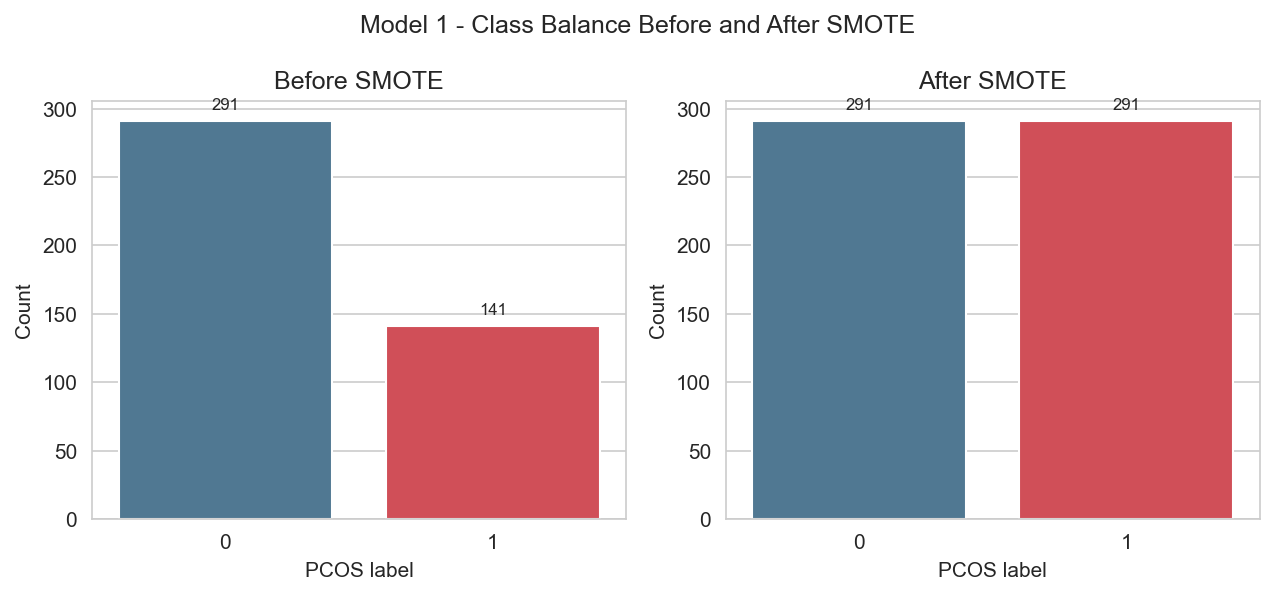

In [114]:
# Plotting the Model 1 SMOTE summary is showing how the non-invasive training set changes after balancing.
fig, axes = plt.subplots(1, 2, figsize=(8.6, 4.0))

before_model1 = model1_smote_table[model1_smote_table["stage"] == "Before SMOTE"]
after_model1 = model1_smote_table[model1_smote_table["stage"] == "After SMOTE"]

sns.barplot(data=before_model1, x="label", y="count", palette=[COLORS["pcos_neg"], COLORS["pcos_pos"]], ax=axes[0])
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("PCOS label")
axes[0].set_ylabel("Count")
annotate_bars(axes[0])

sns.barplot(data=after_model1, x="label", y="count", palette=[COLORS["pcos_neg"], COLORS["pcos_pos"]], ax=axes[1])
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("PCOS label")
axes[1].set_ylabel("Count")
annotate_bars(axes[1])

fig.suptitle("Model 1 - Class Balance Before and After SMOTE")
fig.tight_layout()
output_path = save_figure(fig, "09_model1_smote_balance.png")
print(f"Saved figure to: {output_path}")
plt.show()


In [115]:
# Applying SMOTE to Model 2 is balancing the invasive training set while leaving the test set unchanged.
X2_train_resampled, y2_train_resampled = smote.fit_resample(X2_train_scaled, y_train)

print("Model 2 - class counts after SMOTE:")
print(pd.Series(y2_train_resampled).value_counts().sort_index())
print(f"Model 2 training rows after SMOTE: {X2_train_resampled.shape[0]}")


Model 2 - class counts after SMOTE:
pcos_y_n
0    291
1    291
Name: count, dtype: int64
Model 2 training rows after SMOTE: 582


In [116]:
# Printing the Model 2 before-and-after table is documenting the exact values behind the Model 2 SMOTE balance plot.
model2_smote_table = pd.DataFrame({
    "stage": ["Before SMOTE", "Before SMOTE", "After SMOTE", "After SMOTE"],
    "label": [0, 1, 0, 1],
    "count": [
        int((y_train == 0).sum()),
        int((y_train == 1).sum()),
        int((y2_train_resampled == 0).sum()),
        int((y2_train_resampled == 1).sum()),
    ],
})
print(model2_smote_table)


          stage  label  count
0  Before SMOTE      0    291
1  Before SMOTE      1    141
2   After SMOTE      0    291
3   After SMOTE      1    291


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\feature_engineering\10_model2_smote_balance.png


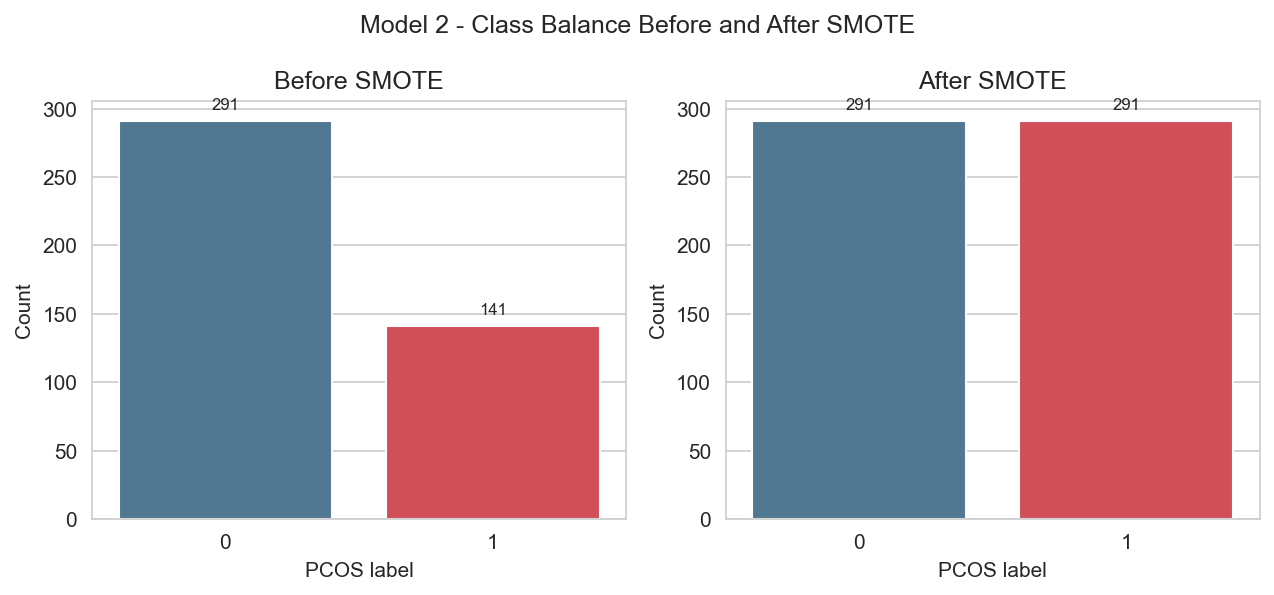

In [117]:
# Plotting the Model 2 SMOTE summary is showing how the invasive training set changes after balancing.
fig, axes = plt.subplots(1, 2, figsize=(8.6, 4.0))

before_model2 = model2_smote_table[model2_smote_table["stage"] == "Before SMOTE"]
after_model2 = model2_smote_table[model2_smote_table["stage"] == "After SMOTE"]

sns.barplot(data=before_model2, x="label", y="count", palette=[COLORS["pcos_neg"], COLORS["pcos_pos"]], ax=axes[0])
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("PCOS label")
axes[0].set_ylabel("Count")
annotate_bars(axes[0])

sns.barplot(data=after_model2, x="label", y="count", palette=[COLORS["pcos_neg"], COLORS["pcos_pos"]], ax=axes[1])
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("PCOS label")
axes[1].set_ylabel("Count")
annotate_bars(axes[1])

fig.suptitle("Model 2 - Class Balance Before and After SMOTE")
fig.tight_layout()
output_path = save_figure(fig, "10_model2_smote_balance.png")
print(f"Saved figure to: {output_path}")
plt.show()


In [118]:
# Printing the combined SMOTE summary table is documenting the values behind the two-model balancing comparison figure.
smote_summary_df = pd.DataFrame({
    "model": ["Model 1", "Model 2"],
    "before_negative": [int((y_train == 0).sum()), int((y_train == 0).sum())],
    "before_positive": [int((y_train == 1).sum()), int((y_train == 1).sum())],
    "after_negative": [int((y1_train_resampled == 0).sum()), int((y2_train_resampled == 0).sum())],
    "after_positive": [int((y1_train_resampled == 1).sum()), int((y2_train_resampled == 1).sum())],
})
print(smote_summary_df)


     model  before_negative  before_positive  after_negative  after_positive
0  Model 1              291              141             291             291
1  Model 2              291              141             291             291


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\feature_engineering\11_both_models_smote_summary.png


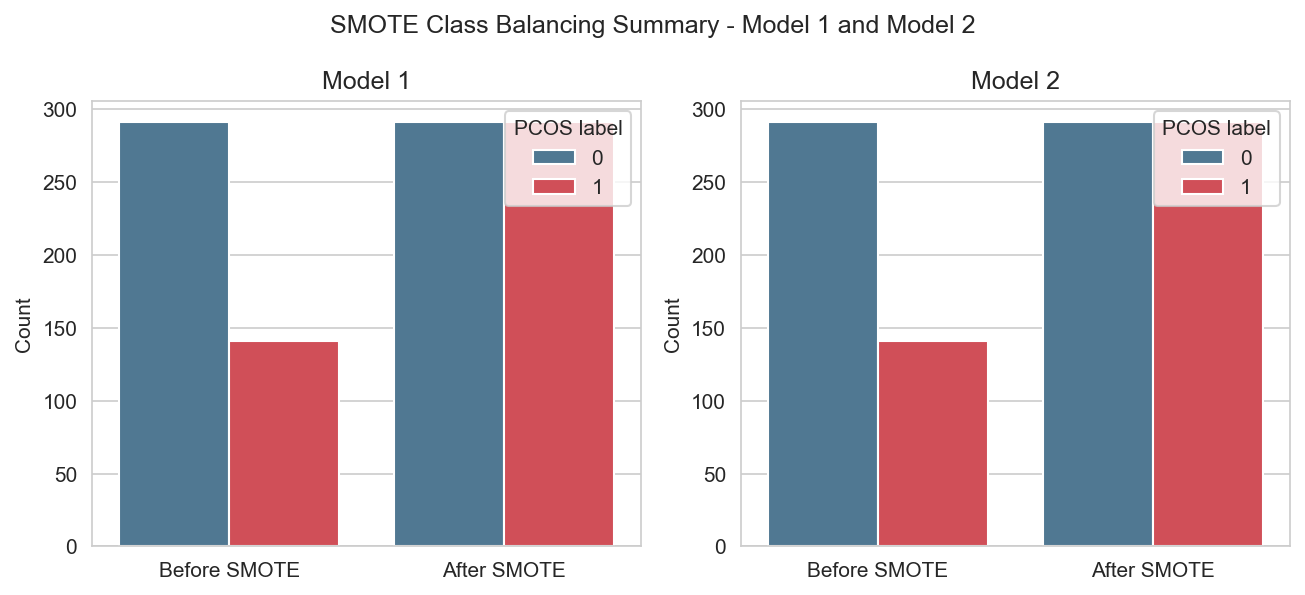

In [119]:
# Plotting the two-model SMOTE comparison is showing the balancing result side by side for the non-invasive and invasive training sets.
fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.0))

for ax, model_name, table in zip(
    axes,
    ["Model 1", "Model 2"],
    [model1_smote_table, model2_smote_table],
):
    sns.barplot(
        data=table,
        x="stage",
        y="count",
        hue="label",
        palette=[COLORS["pcos_neg"], COLORS["pcos_pos"]],
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.legend(title="PCOS label")

fig.suptitle("SMOTE Class Balancing Summary - Model 1 and Model 2")
fig.tight_layout()
output_path = save_figure(fig, "11_both_models_smote_summary.png")
print(f"Saved figure to: {output_path}")
plt.show()


## Section 10 - Saving All Modelling Sets

This section is converting the prepared arrays back into DataFrames, adding the target column as the last field, and saving every modelling file needed by the downstream training notebooks.


In [120]:
# Saving the Model 1 training set is preserving the balanced non-invasive training data with column names and target values.
train1_df = pd.DataFrame(X1_train_resampled, columns=MODEL1_FEATURES)
train1_df[TARGET] = y1_train_resampled.values
model1_train_path = MODELLING_DIR / "model1_train.csv"
train1_df.to_csv(model1_train_path, index=False)
print(f"Saved {model1_train_path} - shape: {train1_df.shape}")
print(train1_df[TARGET].value_counts().sort_index())


Saved C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets\model1_train.csv - shape: (582, 20)
pcos_y_n
0    291
1    291
Name: count, dtype: int64


In [121]:
# Saving the Model 1 test set is preserving the untouched non-invasive evaluation data with the original class balance.
test1_df = pd.DataFrame(X1_test_scaled, columns=MODEL1_FEATURES)
test1_df[TARGET] = y_test.values
model1_test_path = MODELLING_DIR / "model1_test.csv"
test1_df.to_csv(model1_test_path, index=False)
print(f"Saved {model1_test_path} - shape: {test1_df.shape}")
print(test1_df[TARGET].value_counts().sort_index())


Saved C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets\model1_test.csv - shape: (109, 20)
pcos_y_n
0    73
1    36
Name: count, dtype: int64


In [122]:
# Saving the Model 2 training set is preserving the balanced invasive training data with column names and target values.
train2_df = pd.DataFrame(X2_train_resampled, columns=MODEL2_FEATURES)
train2_df[TARGET] = y2_train_resampled.values
model2_train_path = MODELLING_DIR / "model2_train.csv"
train2_df.to_csv(model2_train_path, index=False)
print(f"Saved {model2_train_path} - shape: {train2_df.shape}")
print(train2_df[TARGET].value_counts().sort_index())


Saved C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets\model2_train.csv - shape: (582, 16)
pcos_y_n
0    291
1    291
Name: count, dtype: int64


In [123]:
# Saving the Model 2 test set is preserving the untouched invasive evaluation data with the original class balance.
test2_df = pd.DataFrame(X2_test_scaled, columns=MODEL2_FEATURES)
test2_df[TARGET] = y_test.values
model2_test_path = MODELLING_DIR / "model2_test.csv"
test2_df.to_csv(model2_test_path, index=False)
print(f"Saved {model2_test_path} - shape: {test2_df.shape}")
print(test2_df[TARGET].value_counts().sort_index())


Saved C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets\model2_test.csv - shape: (109, 16)
pcos_y_n
0    73
1    36
Name: count, dtype: int64


In [124]:
# Saving the feature-name files is locking the exact column order expected by downstream notebooks.
feature_names_model1_path = MODELLING_DIR / "feature_names_model1.json"
feature_names_model2_path = MODELLING_DIR / "feature_names_model2.json"

with feature_names_model1_path.open("w", encoding="utf-8") as file_handle:
    json.dump(MODEL1_FEATURES, file_handle, indent=2)
with feature_names_model2_path.open("w", encoding="utf-8") as file_handle:
    json.dump(MODEL2_FEATURES, file_handle, indent=2)

print(f"Saved {feature_names_model1_path} - {len(MODEL1_FEATURES)} features")
print(MODEL1_FEATURES)
print()
print(f"Saved {feature_names_model2_path} - {len(MODEL2_FEATURES)} features")
print(MODEL2_FEATURES)


Saved C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets\feature_names_model1.json - 19 features
['age_yrs', 'bmi', 'cycle_regularity_binary', 'cycle_length_days', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n', 'fast_food_y_n', 'regular_exercise_y_n', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'waist_hip_ratio', 'rbs_mg_dl', 'symptom_burden', 'bmi_category', 'bp_elevated_flag', 'lifestyle_risk']

Saved C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets\feature_names_model2.json - 15 features
['amh_ng_ml', 'fsh_miu_ml', 'lh_miu_ml', 'fsh_lh_ratio', 'tsh_miu_l', 'prl_ng_ml', 'vit_d3_ng_ml', 'prg_ng_ml', 'beta_hcg_i_miu_ml', 'beta_hcg_ii_miu_ml', 'follicle_no_left', 'follicle_no_right', 'avg_follicle_size_left_mm', 'avg_follicle_size_right_mm', 'endometrium_mm']


In [125]:
# Saving the shared cross-validation object is locking the fold logic that all downstream notebooks must use.
cv_strategy = StratifiedKFold(
    n_splits=N_CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
cv_strategy_path = MODELS_DIR / "cv_strategy.pkl"
joblib.dump(cv_strategy, cv_strategy_path)
print(f"Saved {cv_strategy_path}")
print(f"Strategy: Stratified {N_CV_FOLDS}-fold cross-validation")
print("Downstream notebooks must load and use this object.")


Saved C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\cv_strategy.pkl
Strategy: Stratified 10-fold cross-validation
Downstream notebooks must load and use this object.


## Section 11 - Survey External Validation

This section is preparing the survey dataset as an external-style validation table for Model 1 only. The survey data is not being used for training. It is being aligned to the richer non-invasive clinical contract through a mix of direct matches, training-median placeholders, and shared engineered features.

This alignment is limited, not perfect. Some Model 1 clinical fields do not exist in the survey data, so those fields are being filled with medians learned from the Model 1 clinical training rows.


In [126]:
# Printing the survey alignment availability table is showing which Model 1 base features already exist in the survey dataset and which ones need placeholders.
survey_source_cols = survey_df.columns.tolist()
present_features = [feature for feature in MODEL1_BASE if feature in survey_source_cols]
absent_features = [feature for feature in MODEL1_BASE if feature not in survey_source_cols]

survey_availability_df = pd.DataFrame({
    "feature": MODEL1_BASE,
    "status": ["direct" if feature in present_features else "missing" for feature in MODEL1_BASE],
})

print(survey_availability_df)
print()
print(f"Directly available features: {len(present_features)}")
print(present_features)
print()
print(f"Missing features: {len(absent_features)}")
print(absent_features)


                    feature   status
0                   age_yrs   direct
1                       bmi   direct
2   cycle_regularity_binary  missing
3         cycle_length_days   direct
4           weight_gain_y_n   direct
5           hair_growth_y_n   direct
6        skin_darkening_y_n   direct
7             hair_loss_y_n   direct
8               pimples_y_n   direct
9             fast_food_y_n   direct
10     regular_exercise_y_n   direct
11         systolic_bp_mmhg  missing
12        diastolic_bp_mmhg  missing
13          waist_hip_ratio  missing
14                rbs_mg_dl  missing

Directly available features: 10
['age_yrs', 'bmi', 'cycle_length_days', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n', 'fast_food_y_n', 'regular_exercise_y_n']

Missing features: 5
['cycle_regularity_binary', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'waist_hip_ratio', 'rbs_mg_dl']


In [127]:
# Renaming the survey cycle field is aligning the survey dataset to the shared binary cycle field used by Model 1.
if "cycle_regularity" in survey_df.columns:
    survey_df = survey_df.rename(columns={"cycle_regularity": "cycle_regularity_binary"})

print("Survey cycle_regularity_binary counts:")
print(survey_df["cycle_regularity_binary"].value_counts().sort_index())
print()
print("Clinical cycle_regularity_binary counts:")
print(df["cycle_regularity_binary"].value_counts().sort_index())

assert set(survey_df["cycle_regularity_binary"].unique()) <= {0, 1}, "Survey cycle field contains values outside 0 and 1."
print()
print("Survey cycle regularity field aligned successfully.")


Survey cycle_regularity_binary counts:
cycle_regularity_binary
0     99
1    365
Name: count, dtype: int64

Clinical cycle_regularity_binary counts:
cycle_regularity_binary
0    151
1    390
Name: count, dtype: int64

Survey cycle regularity field aligned successfully.


In [128]:
# Creating the absent survey columns is filling missing clinical-only Model 1 fields with medians learned from the clinical training rows.
survey_fill_rows = []
for feature in absent_features:
    fill_value = model1_fill_values[feature]
    survey_df[feature] = fill_value
    survey_fill_rows.append({
        "feature": feature,
        "fill_value": fill_value,
        "note": "Filled from Model 1 clinical training median",
    })

survey_fill_df = pd.DataFrame(survey_fill_rows)
print(survey_fill_df if not survey_fill_df.empty else "No missing survey columns needed placeholder values.")


                   feature  fill_value  \
0  cycle_regularity_binary      1.0000   
1         systolic_bp_mmhg    110.0000   
2        diastolic_bp_mmhg     80.0000   
3          waist_hip_ratio      0.8947   
4                rbs_mg_dl    100.0000   

                                           note  
0  Filled from Model 1 clinical training median  
1  Filled from Model 1 clinical training median  
2  Filled from Model 1 clinical training median  
3  Filled from Model 1 clinical training median  
4  Filled from Model 1 clinical training median  


In [129]:
# Applying shared Model 1 preprocessing to the survey data is aligning the survey table to the full non-invasive contract before scaling.
survey_df = apply_fill_values(survey_df, model1_fill_values)

survey_df["symptom_burden"] = survey_df[symptom_cols].sum(axis=1)
survey_df["bmi_category"] = survey_df["bmi"].apply(bmi_to_category)
survey_df["bp_elevated_flag"] = (
    (survey_df["systolic_bp_mmhg"] >= 130) |
    (survey_df["diastolic_bp_mmhg"] >= 80)
).astype(int)
survey_df["lifestyle_risk"] = survey_df["fast_food_y_n"] + (1 - survey_df["regular_exercise_y_n"])

print("Survey engineered feature preview:")
print(survey_df[["symptom_burden", "bmi_category", "bp_elevated_flag", "lifestyle_risk"]].head())
print()
print("Limitation note: blood-pressure features in the survey validation table are placeholder-filled from the clinical training medians because the raw survey dataset does not collect them directly.")


Survey engineered feature preview:
   symptom_burden  bmi_category  bp_elevated_flag  lifestyle_risk
0               0             0                 1               1
1               3             0                 1               1
2               1             0                 1               2
3               0             1                 1               1
4               1             0                 1               1

Limitation note: blood-pressure features in the survey validation table are placeholder-filled from the clinical training medians because the raw survey dataset does not collect them directly.


In [130]:
# Scaling and saving the survey validation table is preparing the external-style validation set using the Model 1 scaler without refitting it.
X_survey = survey_df[MODEL1_FEATURES].copy()
X_survey_scaled = scaler1.transform(X_survey)

survey_val_df = pd.DataFrame(X_survey_scaled, columns=MODEL1_FEATURES)
survey_val_df[TARGET] = survey_df[TARGET].values

survey_validation_path = MODELLING_DIR / "survey_external_validation.csv"
survey_val_df.to_csv(survey_validation_path, index=False)
print(f"Saved {survey_validation_path} - shape: {survey_val_df.shape}")
print(survey_val_df[TARGET].value_counts().sort_index())


Saved C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets\survey_external_validation.csv - shape: (464, 20)
pcos_y_n
0    363
1    101
Name: count, dtype: int64


In [131]:
# Printing the survey alignment summary table is documenting which Model 1 features are direct, placeholder-filled, or derived in the survey validation set.
alignment_rows = []
derived_features = {"symptom_burden", "bmi_category", "bp_elevated_flag", "lifestyle_risk"}
direct_features = set(present_features)
missing_features_set = set(absent_features)

for feature in MODEL1_FEATURES:
    if feature in derived_features:
        status = "derived"
    elif feature in missing_features_set:
        status = "imputed"
    else:
        status = "direct"
    alignment_rows.append({"feature": feature, "status": status})

survey_alignment_summary_df = pd.DataFrame(alignment_rows)
print(survey_alignment_summary_df)


                    feature   status
0                   age_yrs   direct
1                       bmi   direct
2   cycle_regularity_binary  imputed
3         cycle_length_days   direct
4           weight_gain_y_n   direct
5           hair_growth_y_n   direct
6        skin_darkening_y_n   direct
7             hair_loss_y_n   direct
8               pimples_y_n   direct
9             fast_food_y_n   direct
10     regular_exercise_y_n   direct
11         systolic_bp_mmhg  imputed
12        diastolic_bp_mmhg  imputed
13          waist_hip_ratio  imputed
14                rbs_mg_dl  imputed
15           symptom_burden  derived
16             bmi_category  derived
17         bp_elevated_flag  derived
18           lifestyle_risk  derived



Survey alignment counts:
    status  count
0   direct     10
1  imputed      5
2  derived      4
Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\feature_engineering\13_survey_alignment_summary.png


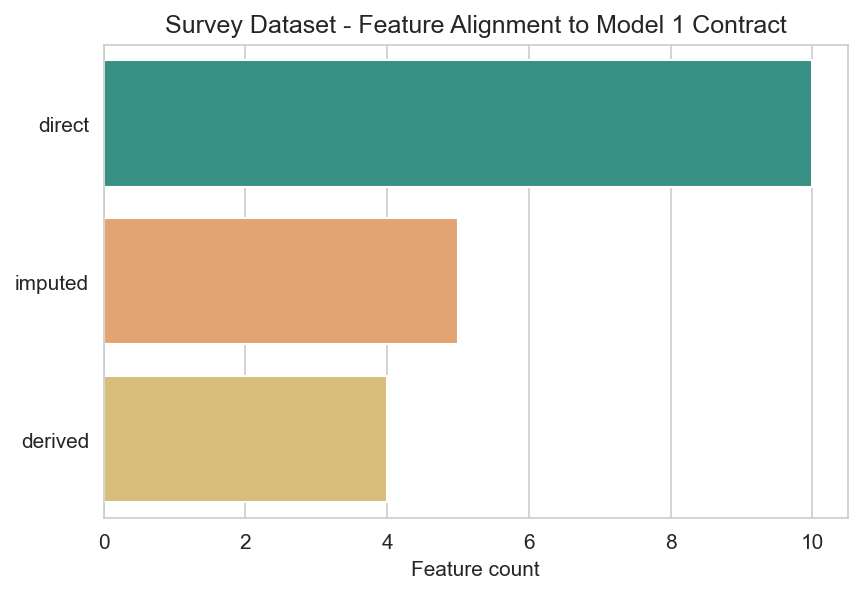

In [132]:
# Plotting the survey alignment summary is showing how many Model 1 features are direct, imputed, or derived in the survey validation table.
alignment_plot_df = (
    survey_alignment_summary_df["status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="count")
)
print()
print("Survey alignment counts:")
print(alignment_plot_df)

fig, ax = plt.subplots(figsize=(6.4, 4.1))
sns.barplot(
    data=alignment_plot_df,
    y="status",
    x="count",
    palette=[COLORS["model1"], COLORS["highlight"], COLORS["model2"]],
    ax=ax,
)
ax.set_title("Survey Dataset - Feature Alignment to Model 1 Contract")
ax.set_xlabel("Feature count")
ax.set_ylabel("")
output_path = save_figure(fig, "13_survey_alignment_summary.png")
print(f"Saved figure to: {output_path}")
plt.show()


## Section 12 - Final Verification and Summary

This section is reloading the saved files, checking that they exist and are non-empty, and closing the notebook with a clean summary of what has been prepared for Notebook 08.


In [133]:
# Reloading the saved outputs is confirming that every required modelling file, scaler, and figure has been written successfully.
csv_files = [
    MODELLING_DIR / "model1_train.csv",
    MODELLING_DIR / "model1_test.csv",
    MODELLING_DIR / "model2_train.csv",
    MODELLING_DIR / "model2_test.csv",
    MODELLING_DIR / "survey_external_validation.csv",
]
json_files = [
    MODELLING_DIR / "feature_names_model1.json",
    MODELLING_DIR / "feature_names_model2.json",
]
pkl_files = [
    MODELS_DIR / "scaler_model1.pkl",
    MODELS_DIR / "scaler_model2.pkl",
    MODELS_DIR / "cv_strategy.pkl",
]
image_files = [
    IMAGE_DIR / "01_class_distribution_source.png",
    IMAGE_DIR / "02_cycle_regularity_remap.png",
    IMAGE_DIR / "03_model1_mutual_information.png",
    IMAGE_DIR / "04_model1_spearman_correlation.png",
    IMAGE_DIR / "05_model1_rf_importances.png",
    IMAGE_DIR / "06_model1_feature_consensus.png",
    IMAGE_DIR / "07_model1_engineered_features.png",
    IMAGE_DIR / "08_model2_invasive_overview.png",
    IMAGE_DIR / "09_model1_smote_balance.png",
    IMAGE_DIR / "10_model2_smote_balance.png",
    IMAGE_DIR / "11_both_models_smote_summary.png",
    IMAGE_DIR / "12_feature_count_comparison.png",
    IMAGE_DIR / "13_survey_alignment_summary.png",
]

for file_path in csv_files:
    loaded = pd.read_csv(file_path)
    print(f"{file_path.name} - shape: {loaded.shape}")

print()
for file_path in json_files:
    with file_path.open("r", encoding="utf-8") as file_handle:
        loaded = json.load(file_handle)
    print(f"{file_path.name} - entries: {len(loaded)}")

print()
for file_path in pkl_files:
    loaded = joblib.load(file_path)
    print(f"{file_path.name} - type: {type(loaded)}")

print()
missing_or_empty = []
all_required_files = csv_files + json_files + pkl_files + image_files
for file_path in all_required_files:
    if (not file_path.exists()) or file_path.stat().st_size == 0:
        missing_or_empty.append(str(file_path))

if missing_or_empty:
    print("Missing or empty files:")
    for item in missing_or_empty:
        print(f"- {item}")
else:
    print("All required files exist and are non-empty.")
    for file_path in all_required_files:
        print(f"OK - {file_path}")


model1_train.csv - shape: (582, 20)
model1_test.csv - shape: (109, 20)
model2_train.csv - shape: (582, 16)
model2_test.csv - shape: (109, 16)
survey_external_validation.csv - shape: (464, 20)

feature_names_model1.json - entries: 19
feature_names_model2.json - entries: 15

scaler_model1.pkl - type: <class 'sklearn.preprocessing._data.MinMaxScaler'>
scaler_model2.pkl - type: <class 'sklearn.preprocessing._data.MinMaxScaler'>
cv_strategy.pkl - type: <class 'sklearn.model_selection._split.StratifiedKFold'>

All required files exist and are non-empty.
OK - C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets\model1_train.csv
OK - C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets\model1_test.csv
OK - C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets\model2_train.csv
OK - C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets\model2_test.csv
OK - C:\

## Notebook Summary and Next Steps

This notebook has prepared the complete modelling inputs for the next phase of the thesis.

The following files have now been defined as the official modelling inputs:

- `model1_train.csv` and `model1_test.csv` for the non-invasive clinical screening model
- `model2_train.csv` and `model2_test.csv` for the invasive benchmark model
- `survey_external_validation.csv` for the external-style check of the non-invasive model
- `feature_names_model1.json` and `feature_names_model2.json` for locked feature order
- `scaler_model1.pkl` and `scaler_model2.pkl` for locked scaling rules
- `cv_strategy.pkl` for locked stratified cross-validation logic

The key technical decisions in this notebook are staying fixed:

- both models are using the same clinical patient split
- imputation values are being learned from training rows only
- scalers are being fitted on training rows only
- SMOTE is being applied to training data only
- the survey dataset is not being used for training

Notebook 08 will train three algorithms on these prepared modelling sets:

- Logistic Regression
- Random Forest
- XGBoost

Those models will be trained on both prepared model sets using the locked cross-validation strategy. The next notebook will report accuracy, precision, recall, F1, AUC-ROC, confusion matrices, and ROC curves, and it will save the trained models to the `models/` folder.
